# Eksperimen Q-Learning Scenario A

State: `(current_node,)` — agen hanya mengetahui node saat ini.

Notebook ini tidak menduplikasi implementasi. Semua konfigurasi, download/load OSM, environment, reward, Q-Learning, metrik, grafik, dan peta berasal dari `rute_lari_core.py`.

In [ ]:
%pip install -q "osmnx>=2.0" networkx numpy pandas geopandas shapely folium matplotlib pyproj

## 1. Muat graf dengan core bersama

Jika GraphML belum ada, fungsi berikut mengunduh data OSM dengan konfigurasi yang sama seperti notebook analisis. Jika sudah ada, GraphML dimuat tanpa mengunduh ulang.

In [34]:
import importlib
import rute_lari_core

# Memuat ulang core agar perubahan grafik terbaru terbaca tanpa restart kernel.
importlib.reload(rute_lari_core)

from rute_lari_core import (
    load_or_download_graph,
    run_scenario_experiment,
    EPISODES,
    SEEDS,
)

G, START_NODE, GRAPH_PATH, downloaded_now = load_or_download_graph()

print(f'Graf: {G.number_of_nodes():,} node, {G.number_of_edges():,} edge')
print(f'Node start: {START_NODE}')
print(f'GraphML: {GRAPH_PATH}')
print('Sumber graf:', 'download baru' if downloaded_now else 'GraphML yang sudah ada')
print(f'Training: {len(SEEDS)} seed × {EPISODES:,} episode')

Graf: 8,027 node, 21,374 edge
Node start: 1720975931
GraphML: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/data_osm_5km/graf_jalan_kaki_5km.graphml
Sumber graf: GraphML yang sudah ada
Training: 5 seed × 10,000 episode


## 2. Eksperimen pendahuluan: epsilon decay dinamis

Pada Scenario A, epsilon turun dari 1,00 ke 0,05 selama seluruh jumlah episode training. Karena lama fase eksplorasi ikut berubah, kelompok ini hanya digunakan untuk menunjukkan pengaruh jadwal epsilon relatif terhadap total episode; bukan pembandingan durasi training final.

Setiap titik melatih ulang lima seed dari awal dengan graf, reward, penyaringan ruas legal, state, dan evaluasi greedy yang sama. Total beban kelompok ini adalah 5 seed × (30.000 + 40.000 + 50.000 + 75.000) = 975.000 episode.


### 2.1 Training 30.000 episode


Menjalankan Scenario A: 5 seed x 30,000 episode
Jadwal epsilon: dinamis mengikuti total episode eksperimen
seed=0: over_distance, 5.66 km, is_loop=False
seed=1: over_distance, 5.52 km, is_loop=False
seed=2: over_distance, 5.54 km, is_loop=False
seed=3: no_available_action, 5.03 km, is_loop=False
seed=4: over_distance, 5.54 km, is_loop=False
Tampilan vertikal metrik evaluasi utama per seed


seed,0,1,2,3,4
is_loop,False,False,False,False,False
total_distance_m,5664.891788,5515.20405,5538.051009,5034.938765,5543.346625
absolute_distance_error_m,664.891788,515.20405,538.051009,34.938765,543.346625
total_reward,-86.991574,-109.943815,-149.080475,-87.800702,-76.609628
mean_comfort,0.637028,0.701505,0.693007,0.714465,0.704004
return_progress_ratio,0.244444,0.156863,0.313433,0.243243,0.326531
distance_to_start_at_end_m,2445.557024,1948.353176,2135.289769,2334.220843,1354.045636
closing_action_available,False,False,False,False,False
termination_reason,over_distance,over_distance,over_distance,no_available_action,over_distance


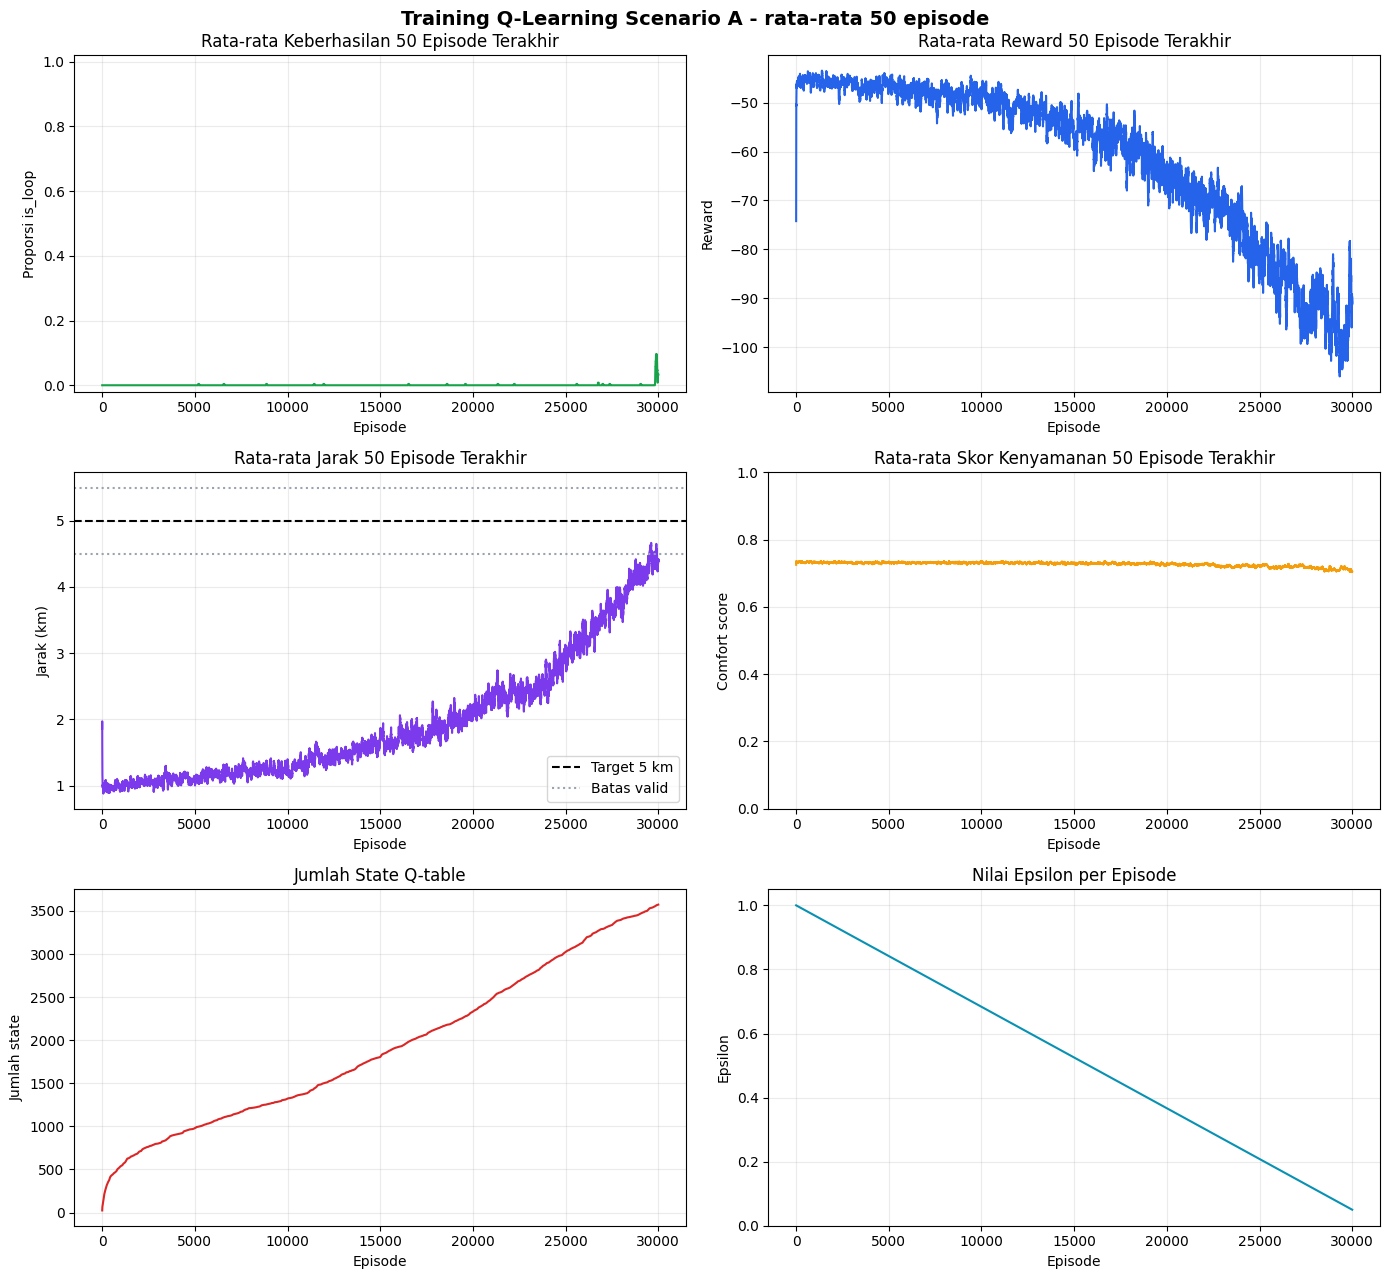

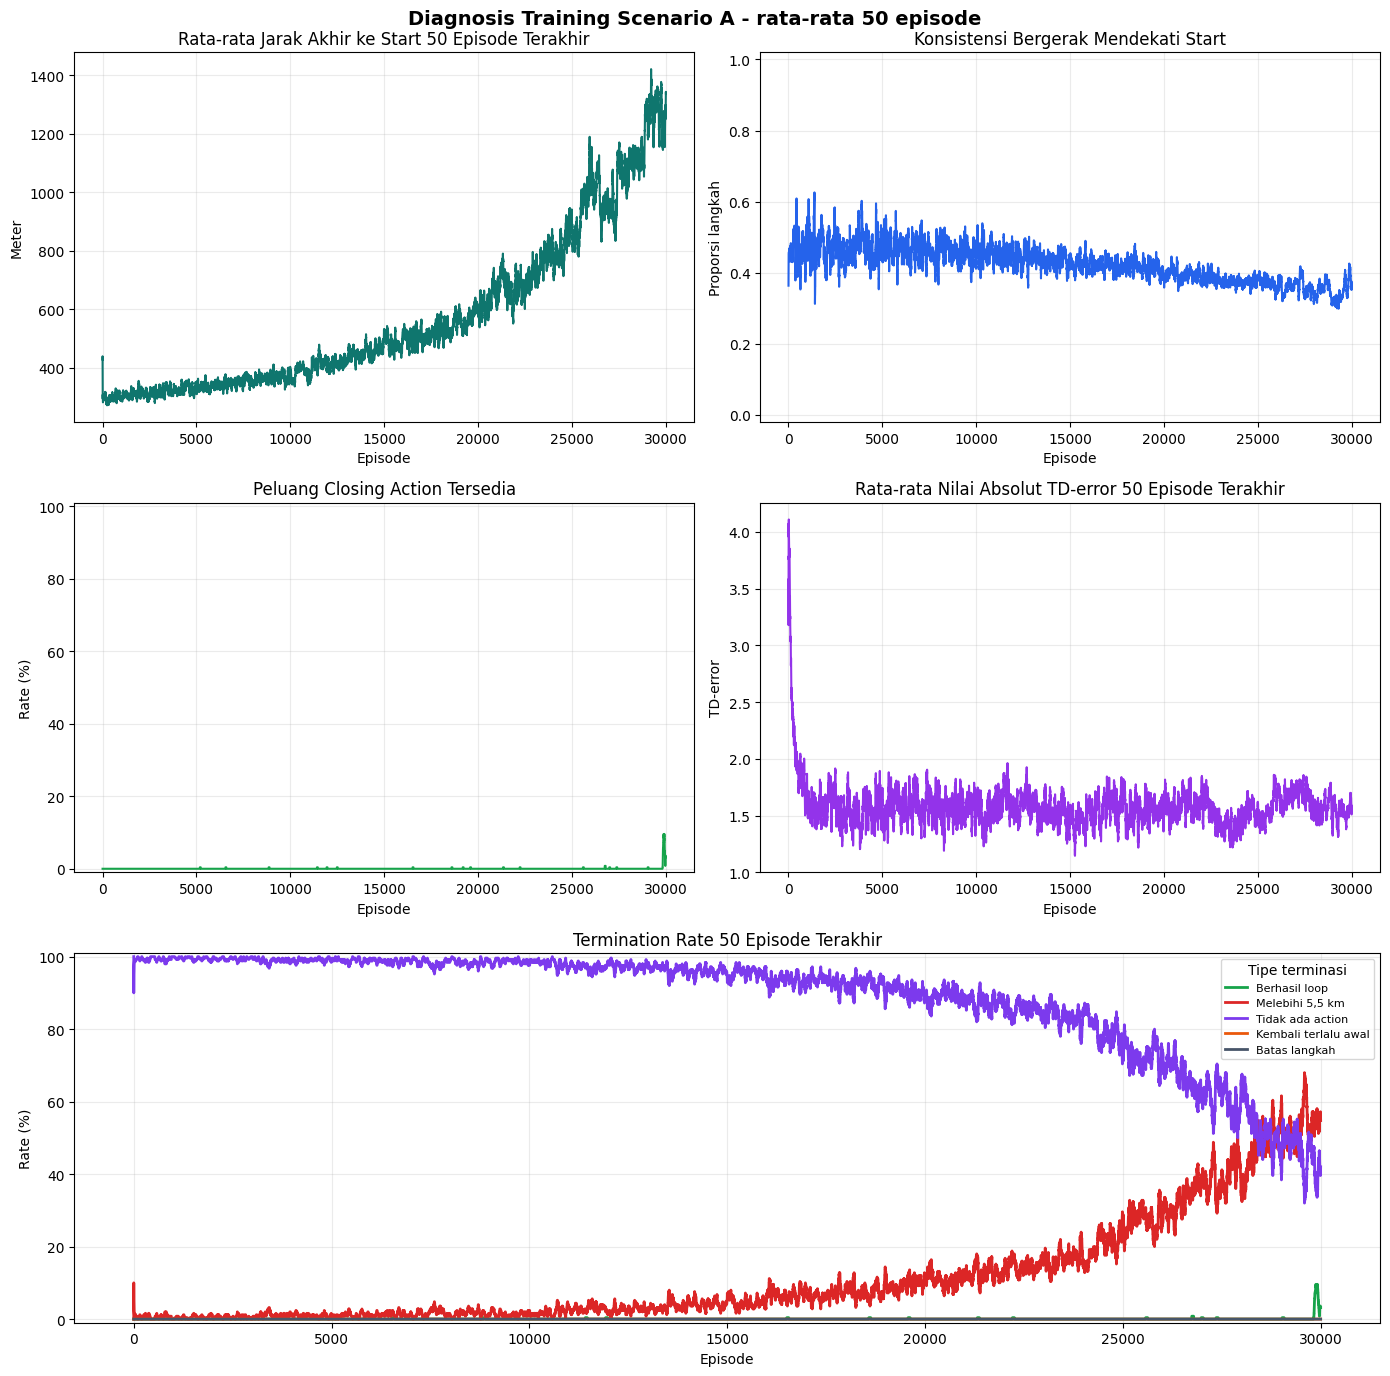

=== Q-TABLE / SEED YANG DIPILIH UNTUK PETA ===
Scenario: A; seed: 3
Metrik: is_loop=False, jarak=5034.94 m, galat=34.94 m, comfort=0.714, return_progress=0.243, jarak akhir ke start=2334.22 m, terminasi=no_available_action
Alasan: Tidak ada loop valid, sehingga dipilih rute dengan galat jarak paling kecil; jika setara, jarak akhir ke start paling kecil, comfort tertinggi, lalu return progress tertinggi.


History: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/sensitivitas_episode_30000_A/training_history_A.csv
Evaluasi: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/sensitivitas_episode_30000_A/evaluation_metrics_A.csv
Diagnosis: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/sensitivitas_episode_30000_A/diagnosis_metrics_A.csv
Termination rate training: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/sensitivitas_episode_30000_A/termination_rates_training_A.csv
Termination rate evaluasi: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/sensitivitas_episode_30000_A/termination_rates_evaluation_A.csv
Grafik training utama: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/t

In [35]:
import importlib
# Memuat ulang core agar notebook memakai fungsi dan parameter terbaru.
importlib.reload(rute_lari_core)

result_a_30000 = rute_lari_core.run_scenario_experiment(
    G, START_NODE, 'A',
    episodes=30_000,
    result_subdir='sensitivitas_episode_30000_A',
)


### 2.2 Training 40.000 episode


Menjalankan Scenario A: 5 seed x 40,000 episode
Jadwal epsilon: dinamis mengikuti total episode eksperimen
seed=0: over_distance, 5.50 km, is_loop=False
seed=1: over_distance, 5.54 km, is_loop=False
seed=2: over_distance, 5.58 km, is_loop=False
seed=3: over_distance, 5.53 km, is_loop=False
seed=4: over_distance, 5.50 km, is_loop=False
Tampilan vertikal metrik evaluasi utama per seed


seed,0,1,2,3,4
is_loop,False,False,False,False,False
total_distance_m,5502.386202,5539.984339,5576.142016,5527.388219,5503.370156
absolute_distance_error_m,502.386202,539.984339,576.142016,527.388219,503.370156
total_reward,-139.655223,-131.195133,-88.454168,-47.145742,-156.212271
mean_comfort,0.713633,0.702448,0.737618,0.736259,0.703177
return_progress_ratio,0.174603,0.37037,0.295455,0.415094,0.421053
distance_to_start_at_end_m,1597.47819,2136.484257,1746.837824,1622.658431,2089.301496
closing_action_available,False,False,False,False,False
termination_reason,over_distance,over_distance,over_distance,over_distance,over_distance


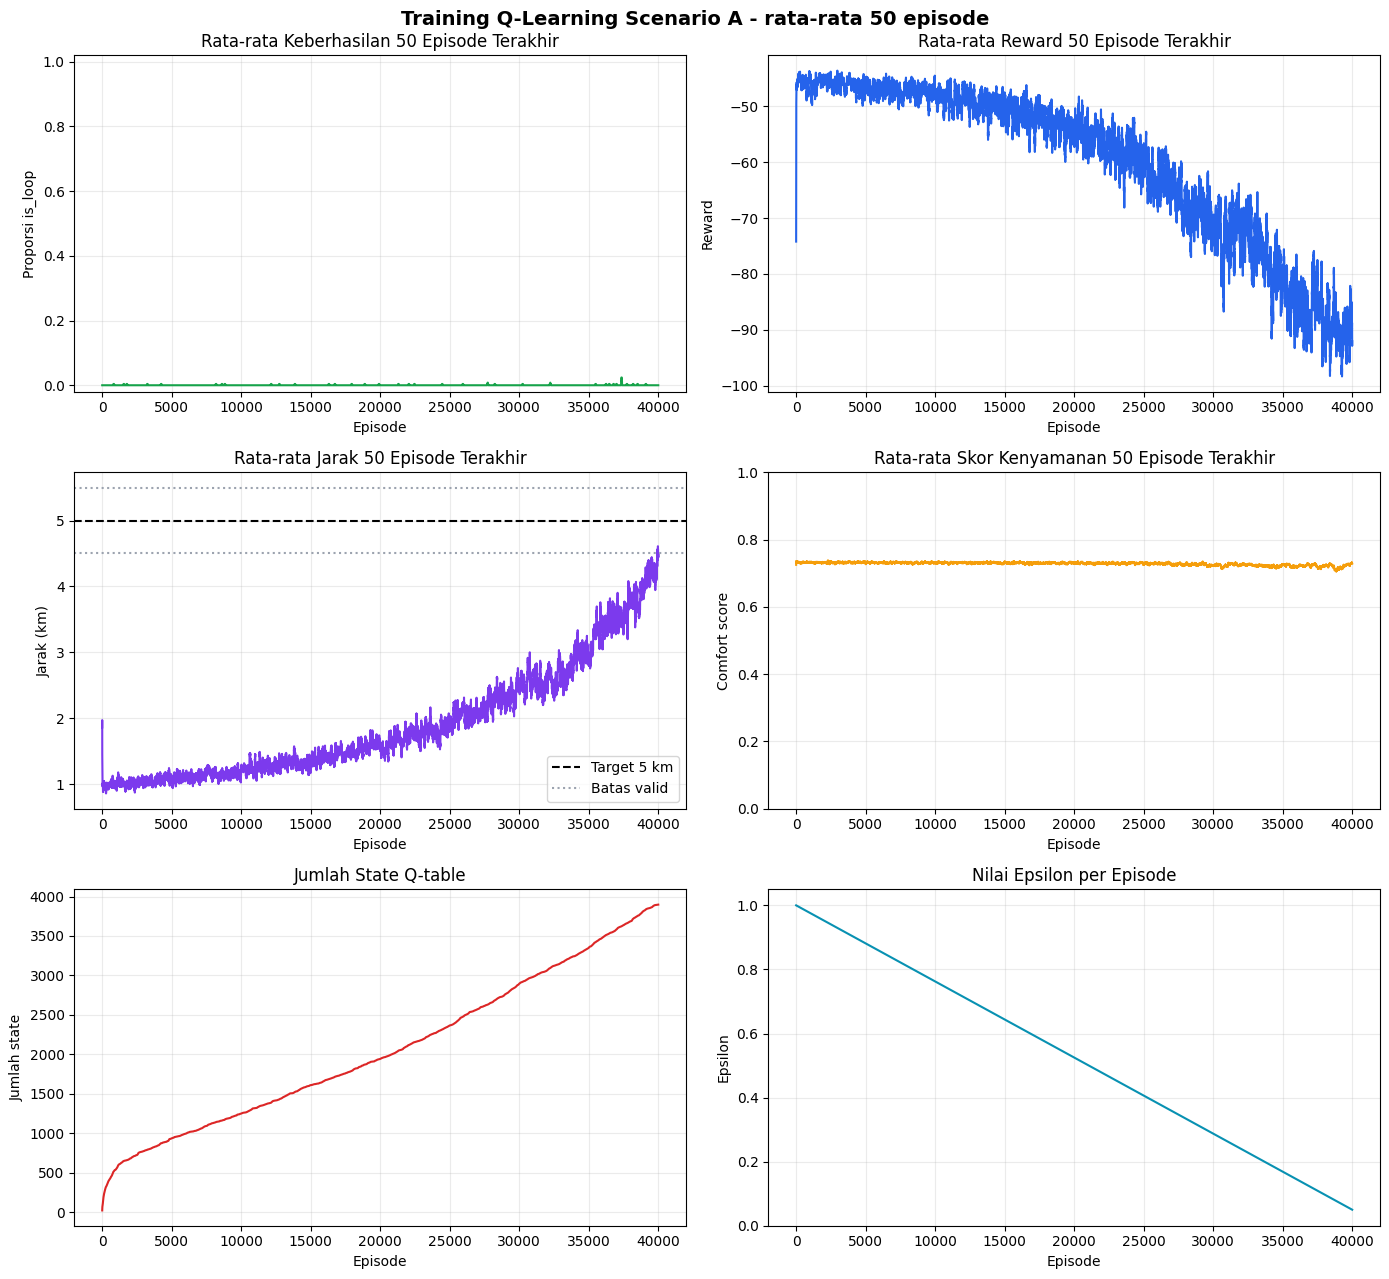

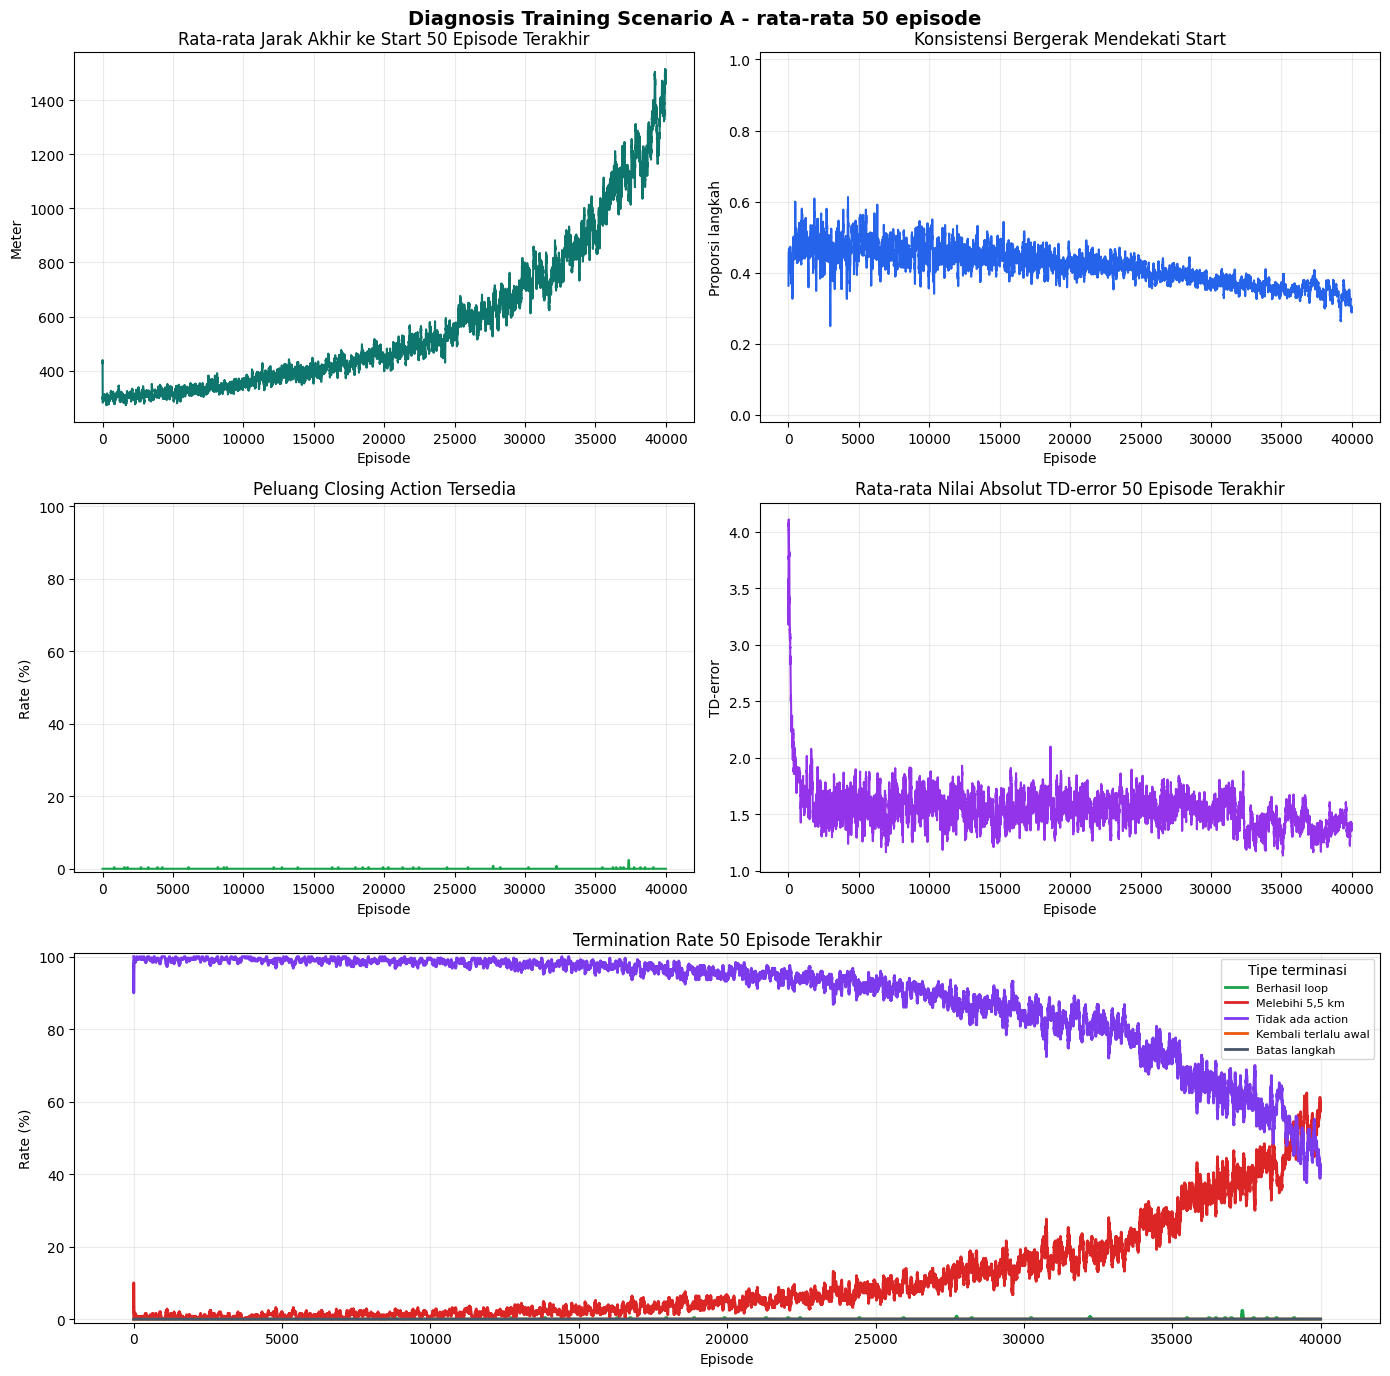

=== Q-TABLE / SEED YANG DIPILIH UNTUK PETA ===
Scenario: A; seed: 0
Metrik: is_loop=False, jarak=5502.39 m, galat=502.39 m, comfort=0.714, return_progress=0.175, jarak akhir ke start=1597.48 m, terminasi=over_distance
Alasan: Tidak ada loop valid, sehingga dipilih rute dengan galat jarak paling kecil; jika setara, jarak akhir ke start paling kecil, comfort tertinggi, lalu return progress tertinggi.


History: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/sensitivitas_episode_40000_A/training_history_A.csv
Evaluasi: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/sensitivitas_episode_40000_A/evaluation_metrics_A.csv
Diagnosis: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/sensitivitas_episode_40000_A/diagnosis_metrics_A.csv
Termination rate training: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/sensitivitas_episode_40000_A/termination_rates_training_A.csv
Termination rate evaluasi: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/sensitivitas_episode_40000_A/termination_rates_evaluation_A.csv
Grafik training utama: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/t

In [36]:
import importlib
# Memuat ulang core agar notebook memakai fungsi dan parameter terbaru.
importlib.reload(rute_lari_core)

result_a_40000 = rute_lari_core.run_scenario_experiment(
    G, START_NODE, 'A',
    episodes=40_000,
    result_subdir='sensitivitas_episode_40000_A',
)


### 2.3 Training 50.000 episode


Menjalankan Scenario A: 5 seed x 50,000 episode
Jadwal epsilon: dinamis mengikuti total episode eksperimen
seed=0: over_distance, 5.60 km, is_loop=False
seed=1: over_distance, 5.51 km, is_loop=False
seed=2: over_distance, 5.52 km, is_loop=False
seed=3: over_distance, 5.51 km, is_loop=False
seed=4: over_distance, 5.60 km, is_loop=False
Tampilan vertikal metrik evaluasi utama per seed


seed,0,1,2,3,4
is_loop,False,False,False,False,False
total_distance_m,5598.521483,5511.675315,5517.275918,5505.994521,5600.680616
absolute_distance_error_m,598.521483,511.675315,517.275918,505.994521,600.680616
total_reward,-74.970748,-76.940963,-133.848368,-61.31648,-87.449833
mean_comfort,0.730868,0.720767,0.755886,0.700994,0.651502
return_progress_ratio,0.26087,0.258621,0.46,0.26,0.2
distance_to_start_at_end_m,1452.149463,1135.978365,1593.843056,1685.626997,2598.648799
closing_action_available,False,False,False,False,False
termination_reason,over_distance,over_distance,over_distance,over_distance,over_distance


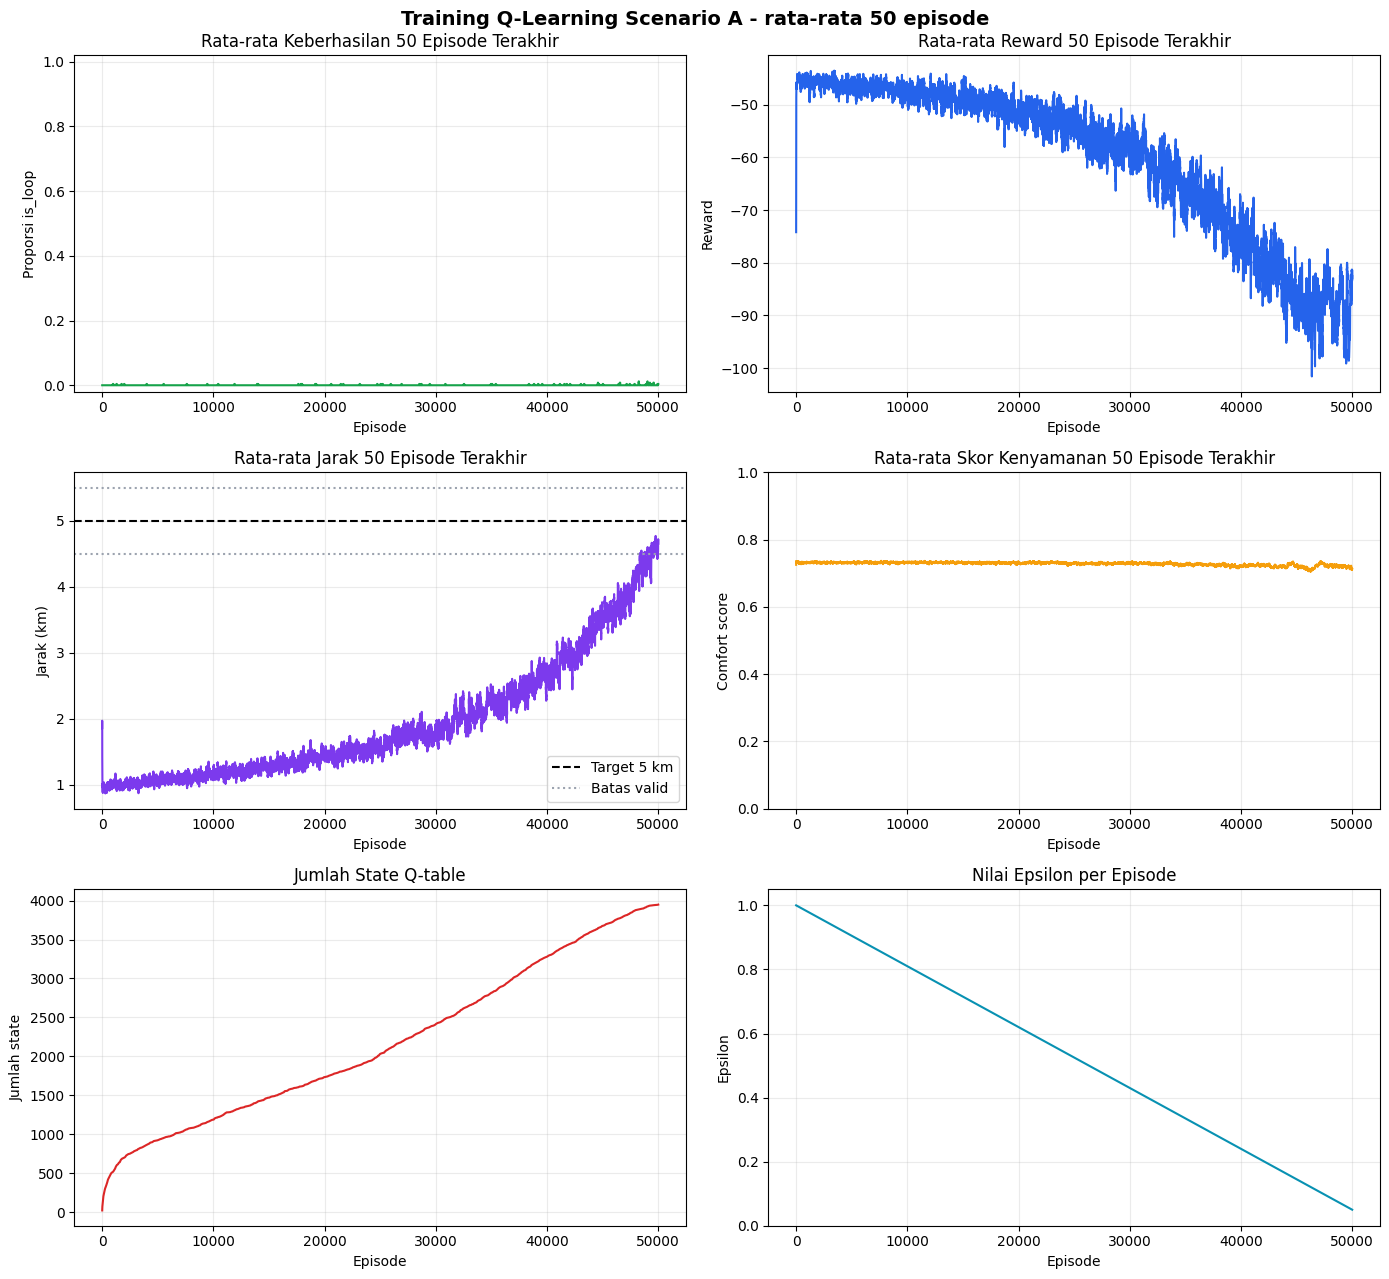

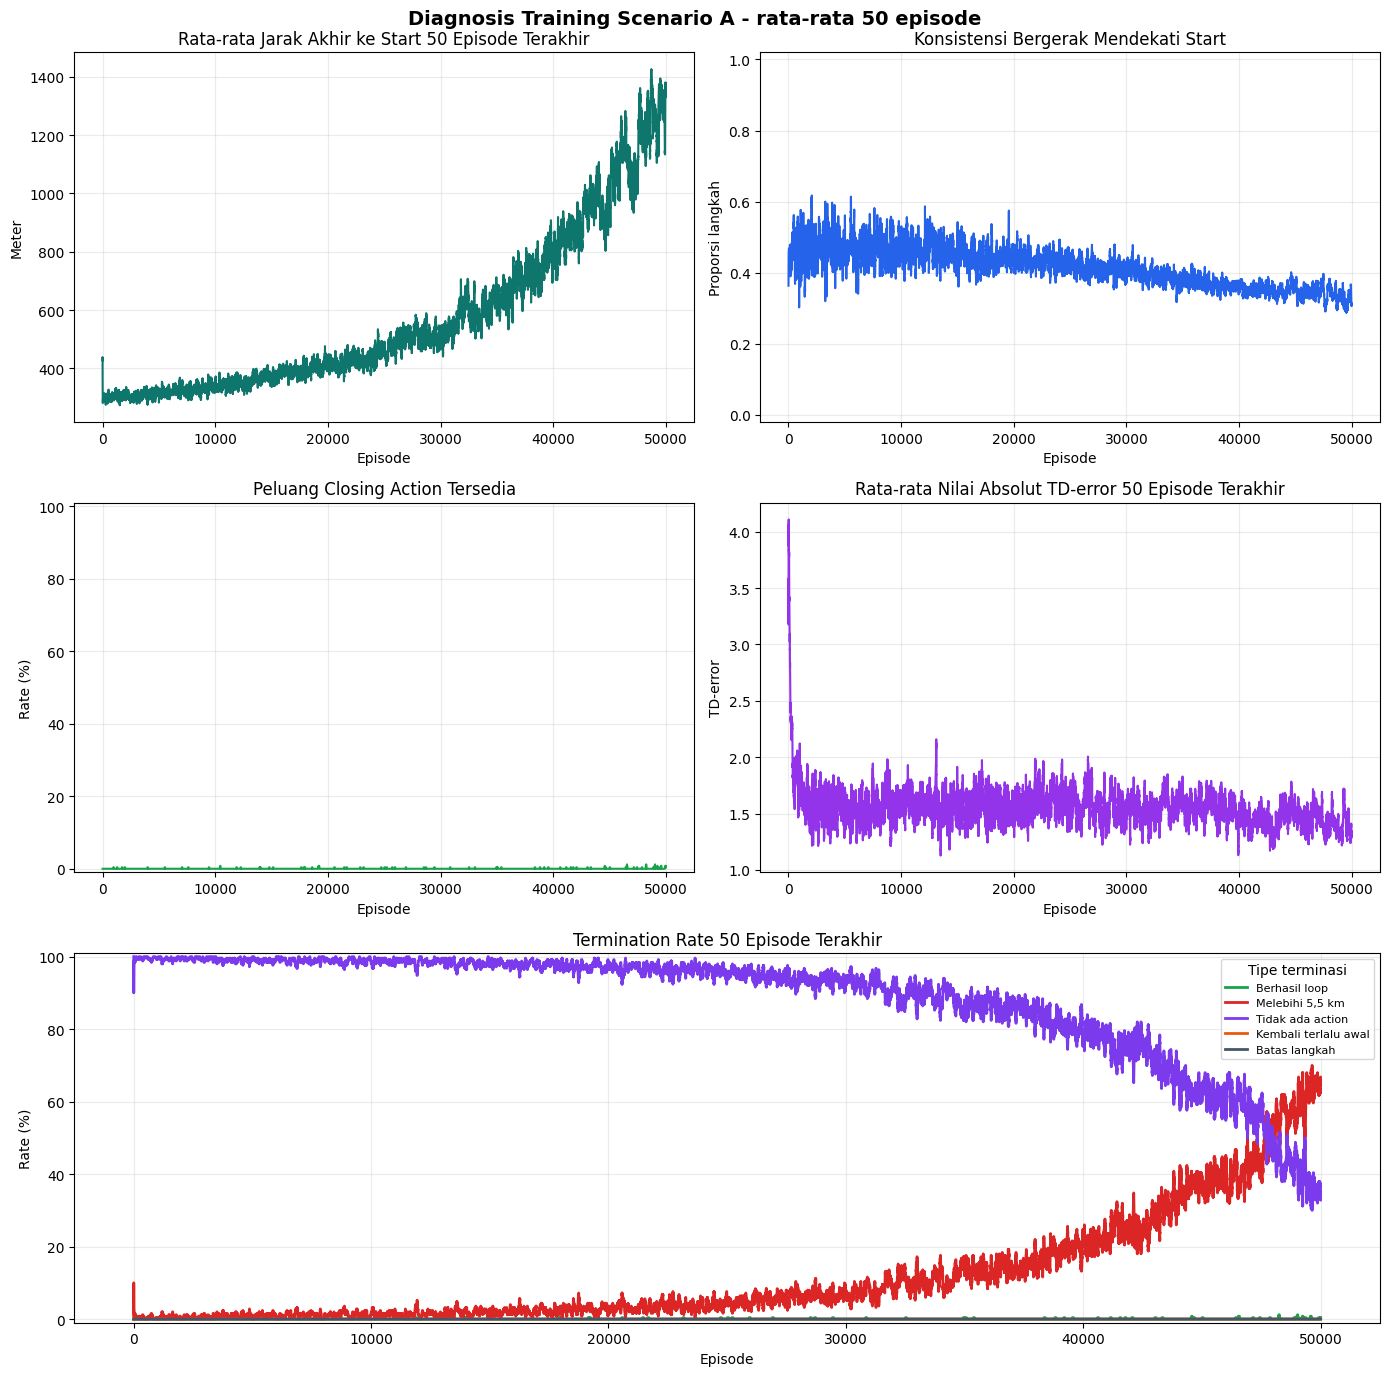

=== Q-TABLE / SEED YANG DIPILIH UNTUK PETA ===
Scenario: A; seed: 3
Metrik: is_loop=False, jarak=5505.99 m, galat=505.99 m, comfort=0.701, return_progress=0.260, jarak akhir ke start=1685.63 m, terminasi=over_distance
Alasan: Tidak ada loop valid, sehingga dipilih rute dengan galat jarak paling kecil; jika setara, jarak akhir ke start paling kecil, comfort tertinggi, lalu return progress tertinggi.


History: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/sensitivitas_episode_50000_A/training_history_A.csv
Evaluasi: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/sensitivitas_episode_50000_A/evaluation_metrics_A.csv
Diagnosis: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/sensitivitas_episode_50000_A/diagnosis_metrics_A.csv
Termination rate training: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/sensitivitas_episode_50000_A/termination_rates_training_A.csv
Termination rate evaluasi: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/sensitivitas_episode_50000_A/termination_rates_evaluation_A.csv
Grafik training utama: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/t

In [37]:
import importlib
# Memuat ulang core agar notebook memakai fungsi dan parameter terbaru.
importlib.reload(rute_lari_core)

result_a_50000 = rute_lari_core.run_scenario_experiment(
    G, START_NODE, 'A',
    episodes=50_000,
    result_subdir='sensitivitas_episode_50000_A',
)


### 2.4 Training 75.000 episode


Menjalankan Scenario A: 5 seed x 75,000 episode
Jadwal epsilon: dinamis mengikuti total episode eksperimen
seed=0: over_distance, 5.52 km, is_loop=False
seed=1: over_distance, 5.51 km, is_loop=False
seed=2: no_available_action, 4.99 km, is_loop=False
seed=3: over_distance, 5.52 km, is_loop=False
seed=4: over_distance, 5.72 km, is_loop=False
Tampilan vertikal metrik evaluasi utama per seed


seed,0,1,2,3,4
is_loop,False,False,False,False,False
total_distance_m,5523.30827,5514.605687,4988.268392,5515.968372,5723.967223
absolute_distance_error_m,523.30827,514.605687,11.731608,515.968372,723.967223
total_reward,-77.519841,-40.003882,-80.132286,-75.305796,-102.412537
mean_comfort,0.67854,0.697658,0.710593,0.732033,0.692191
return_progress_ratio,0.347826,0.482759,0.195652,0.444444,0.210526
distance_to_start_at_end_m,1196.917292,1117.073296,2376.945214,1906.452196,2428.813836
closing_action_available,False,False,False,False,False
termination_reason,over_distance,over_distance,no_available_action,over_distance,over_distance


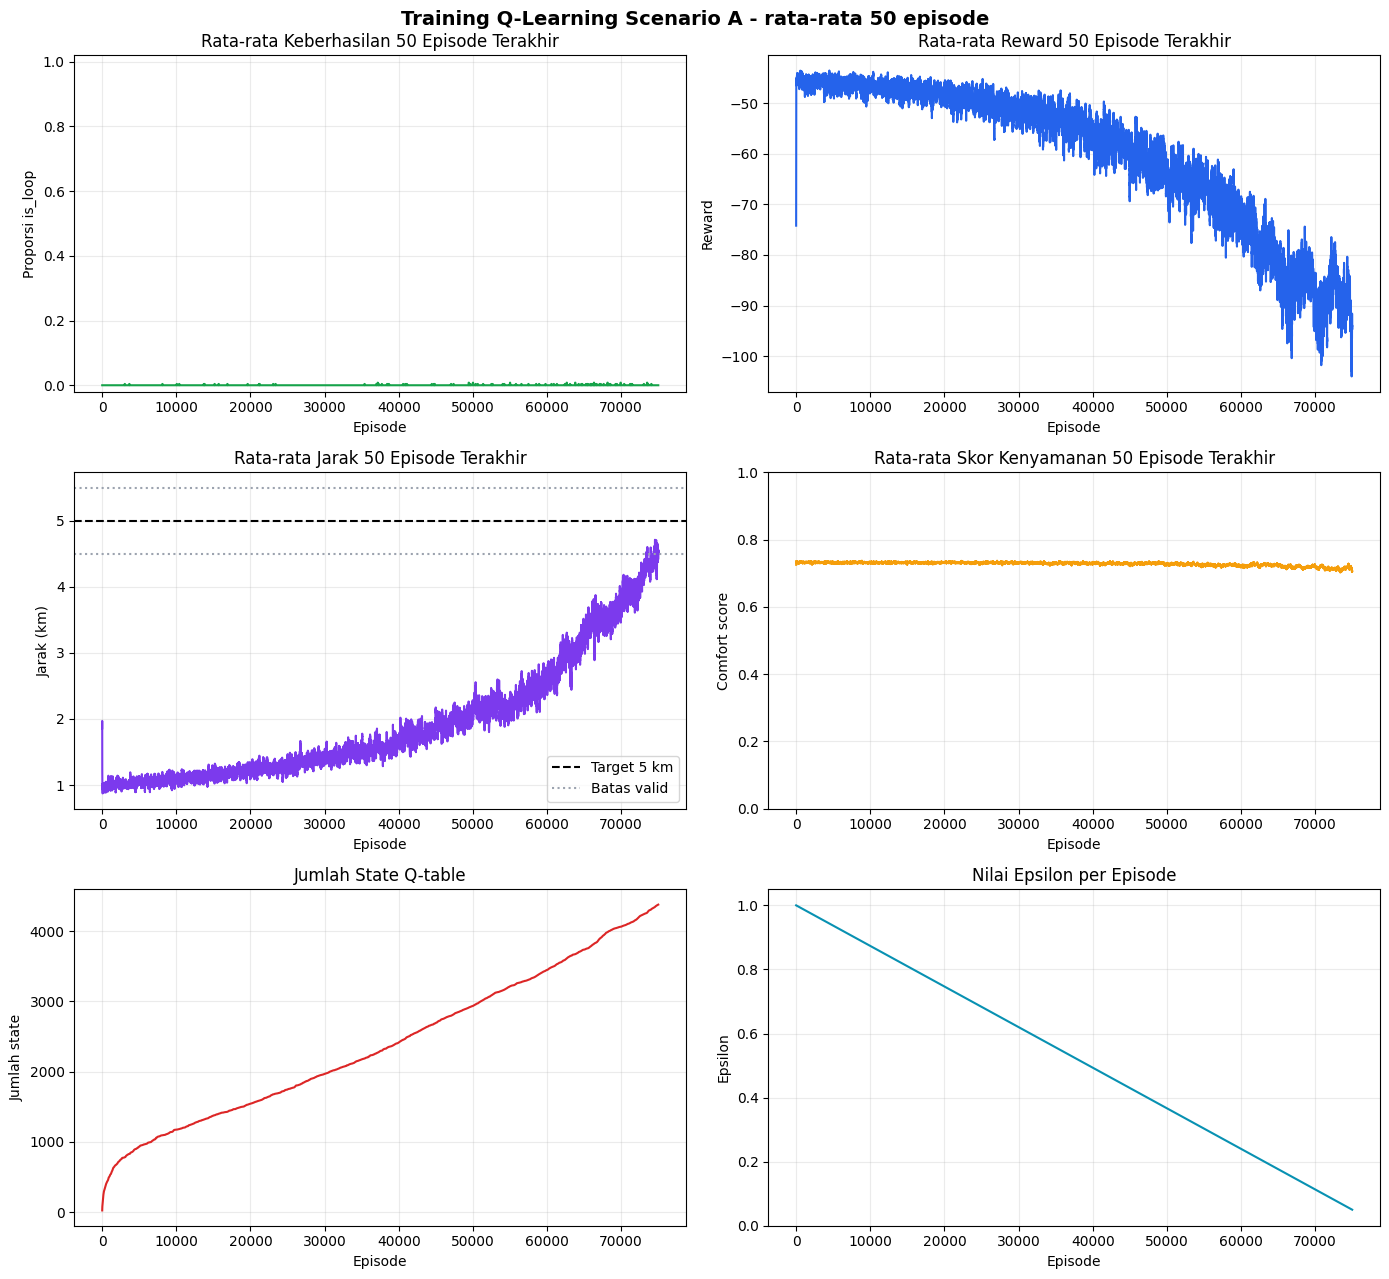

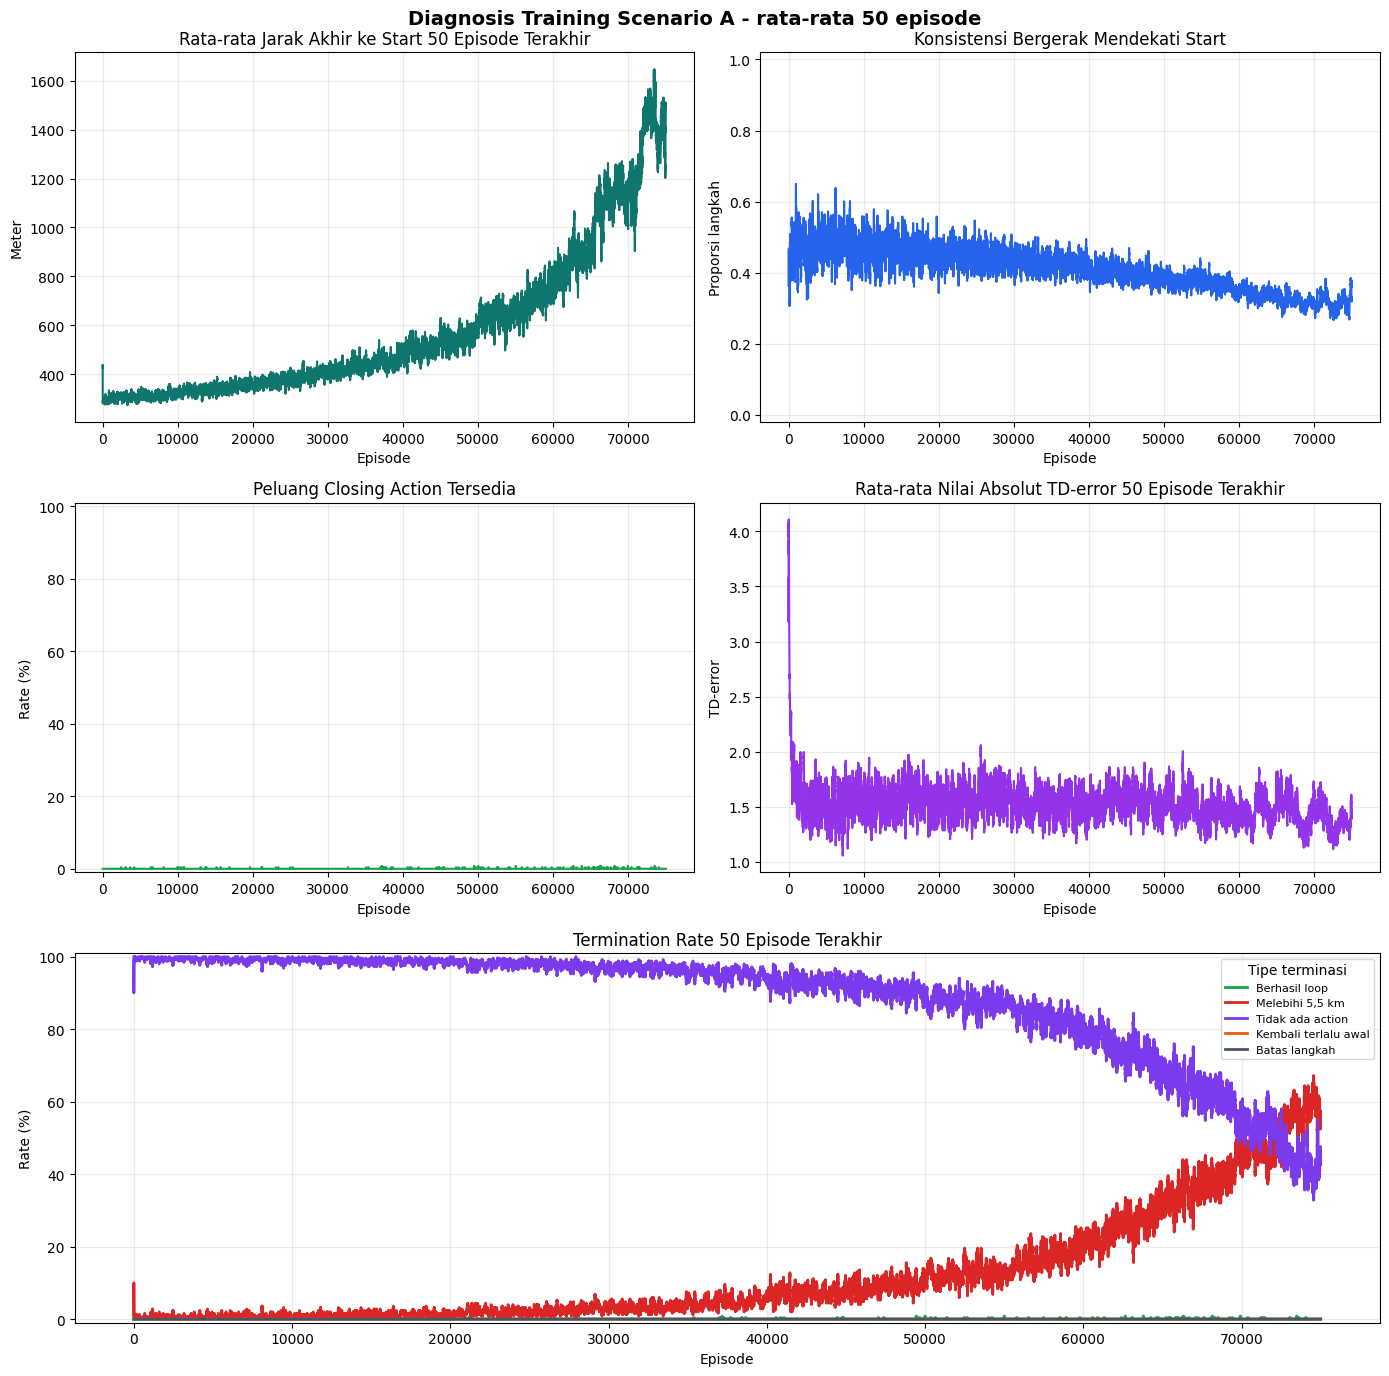

=== Q-TABLE / SEED YANG DIPILIH UNTUK PETA ===
Scenario: A; seed: 2
Metrik: is_loop=False, jarak=4988.27 m, galat=11.73 m, comfort=0.711, return_progress=0.196, jarak akhir ke start=2376.95 m, terminasi=no_available_action
Alasan: Tidak ada loop valid, sehingga dipilih rute dengan galat jarak paling kecil; jika setara, jarak akhir ke start paling kecil, comfort tertinggi, lalu return progress tertinggi.


History: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/sensitivitas_episode_75000_A/training_history_A.csv
Evaluasi: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/sensitivitas_episode_75000_A/evaluation_metrics_A.csv
Diagnosis: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/sensitivitas_episode_75000_A/diagnosis_metrics_A.csv
Termination rate training: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/sensitivitas_episode_75000_A/termination_rates_training_A.csv
Termination rate evaluasi: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/sensitivitas_episode_75000_A/termination_rates_evaluation_A.csv
Grafik training utama: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/t

In [38]:
import importlib
# Memuat ulang core agar notebook memakai fungsi dan parameter terbaru.
importlib.reload(rute_lari_core)

result_a_75000 = rute_lari_core.run_scenario_experiment(
    G, START_NODE, 'A',
    episodes=75_000,
    result_subdir='sensitivitas_episode_75000_A',
)


### 2.5 Ringkasan epsilon decay dinamis

Tabel dan grafik menggunakan evaluasi greedy lima seed pada setiap jumlah episode. Bandingkan terutama keberhasilan loop, galat jarak, konsistensi bergerak mendekati start, dan peluang closing action tersedia.


,episodes,epsilon_decay_episodes,success_rate_greedy,mean_distance_error_m,mean_total_reward,mean_comfort,mean_return_progress_ratio,closing_action_available_rate
0,30000,None,0.0,459.286447,-102.085239,0.690002,0.256903,0.0
1,40000,None,0.0,529.854186,-112.532507,0.718627,0.335315,0.0
2,50000,None,0.0,546.829571,-86.905278,0.712003,0.287898,0.0
3,75000,None,0.0,457.916232,-75.074868,0.702203,0.336242,0.0


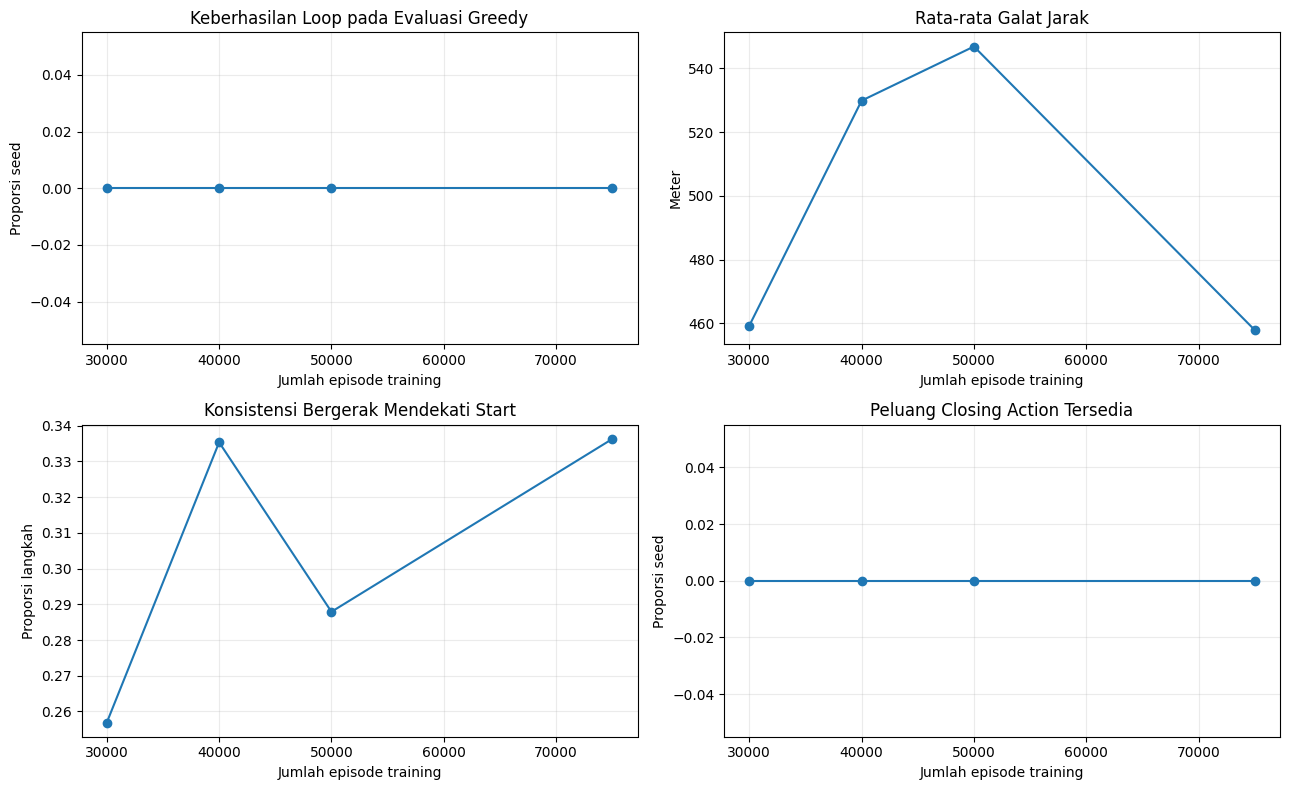

In [39]:
import matplotlib.pyplot as plt
import pandas as pd

# Epsilon turun sepanjang total episode masing-masing percobaan.
# Ringkasan ini adalah eksperimen pendahuluan, bukan dasar perbandingan final.
dynamic_decay_results = {
    30_000: result_a_30000,
    40_000: result_a_40000,
    50_000: result_a_50000,
    75_000: result_a_75000,
}

summary_rows = []
for episodes, result in dynamic_decay_results.items():
    metrics = result['metrics']
    summary_rows.append({
        'episodes': episodes,
        'epsilon_decay_episodes': result['epsilon_decay_episodes'],
        'success_rate_greedy': metrics['is_loop'].mean(),
        'mean_distance_error_m': metrics['absolute_distance_error_m'].mean(),
        'mean_total_reward': metrics['total_reward'].mean(),
        'mean_comfort': metrics['mean_comfort'].mean(),
        'mean_return_progress_ratio': metrics['return_progress_ratio'].mean(),
        'closing_action_available_rate': metrics['closing_action_available'].mean(),
    })

dynamic_decay_sensitivity_df = pd.DataFrame(summary_rows).sort_values('episodes')
display(dynamic_decay_sensitivity_df)

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
plots = [
    ('success_rate_greedy', 'Keberhasilan Loop pada Evaluasi Greedy', 'Proporsi seed'),
    ('mean_distance_error_m', 'Rata-rata Galat Jarak', 'Meter'),
    ('mean_return_progress_ratio', 'Konsistensi Bergerak Mendekati Start', 'Proporsi langkah'),
    ('closing_action_available_rate', 'Peluang Closing Action Tersedia', 'Proporsi seed'),
]
for axis, (column, title, ylabel) in zip(axes.flat, plots):
    axis.plot(dynamic_decay_sensitivity_df['episodes'], dynamic_decay_sensitivity_df[column], marker='o')
    axis.set(title=title, xlabel='Jumlah episode training', ylabel=ylabel)
    axis.grid(alpha=0.25)
plt.tight_layout()
plt.show()


## 3. Eksperimen utama: epsilon decay tetap 50.000 episode

Bagian ini menguji Scenario A pada 50.000, 75.000, 100.000, dan 150.000 episode. Epsilon turun dari 1,00 ke 0,05 hanya selama 50.000 episode pertama, lalu tetap 0,05 sampai training selesai. Dengan demikian, tambahan durasi setelah 50k dapat dibaca sebagai fase perbaikan kebijakan pada tingkat eksplorasi minimum yang sama.

Setiap titik melatih ulang lima seed dari awal. Training 50k dijalankan ulang agar kelompok ini mandiri, walaupun jadwal epsilon-nya secara matematis sama dengan eksperimen dinamis 50k. Total beban kelompok ini adalah 5 seed × (50.000 + 75.000 + 100.000 + 150.000) = 1.875.000 episode.


### 3.1 Training 50.000 episode dengan epsilon decay 50.000


Menjalankan Scenario A: 5 seed x 50,000 episode
Jadwal epsilon: turun selama 50,000 episode, lalu tetap 0.05
seed=0: over_distance, 5.60 km, is_loop=False
seed=1: over_distance, 5.51 km, is_loop=False
seed=2: over_distance, 5.52 km, is_loop=False
seed=3: over_distance, 5.51 km, is_loop=False
seed=4: over_distance, 5.60 km, is_loop=False
Tampilan vertikal metrik evaluasi utama per seed


seed,0,1,2,3,4
is_loop,False,False,False,False,False
total_distance_m,5598.521483,5511.675315,5517.275918,5505.994521,5600.680616
absolute_distance_error_m,598.521483,511.675315,517.275918,505.994521,600.680616
total_reward,-74.970748,-76.940963,-133.848368,-61.31648,-87.449833
mean_comfort,0.730868,0.720767,0.755886,0.700994,0.651502
return_progress_ratio,0.26087,0.258621,0.46,0.26,0.2
distance_to_start_at_end_m,1452.149463,1135.978365,1593.843056,1685.626997,2598.648799
closing_action_available,False,False,False,False,False
termination_reason,over_distance,over_distance,over_distance,over_distance,over_distance


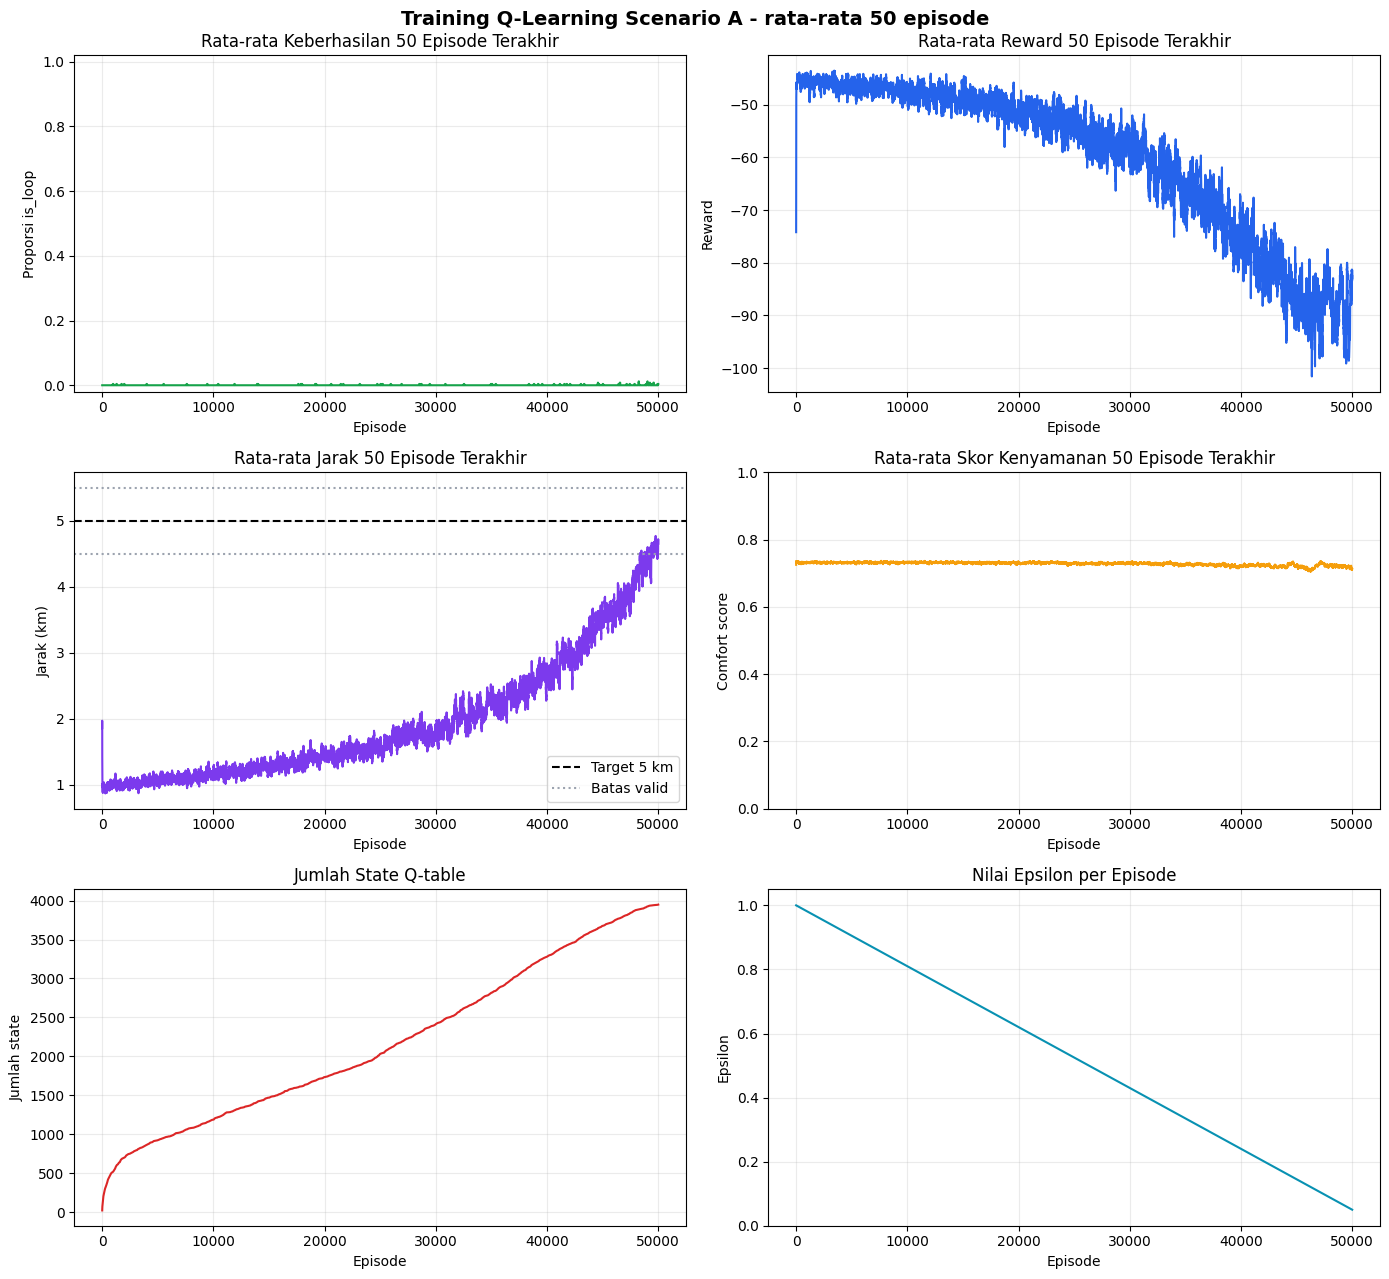

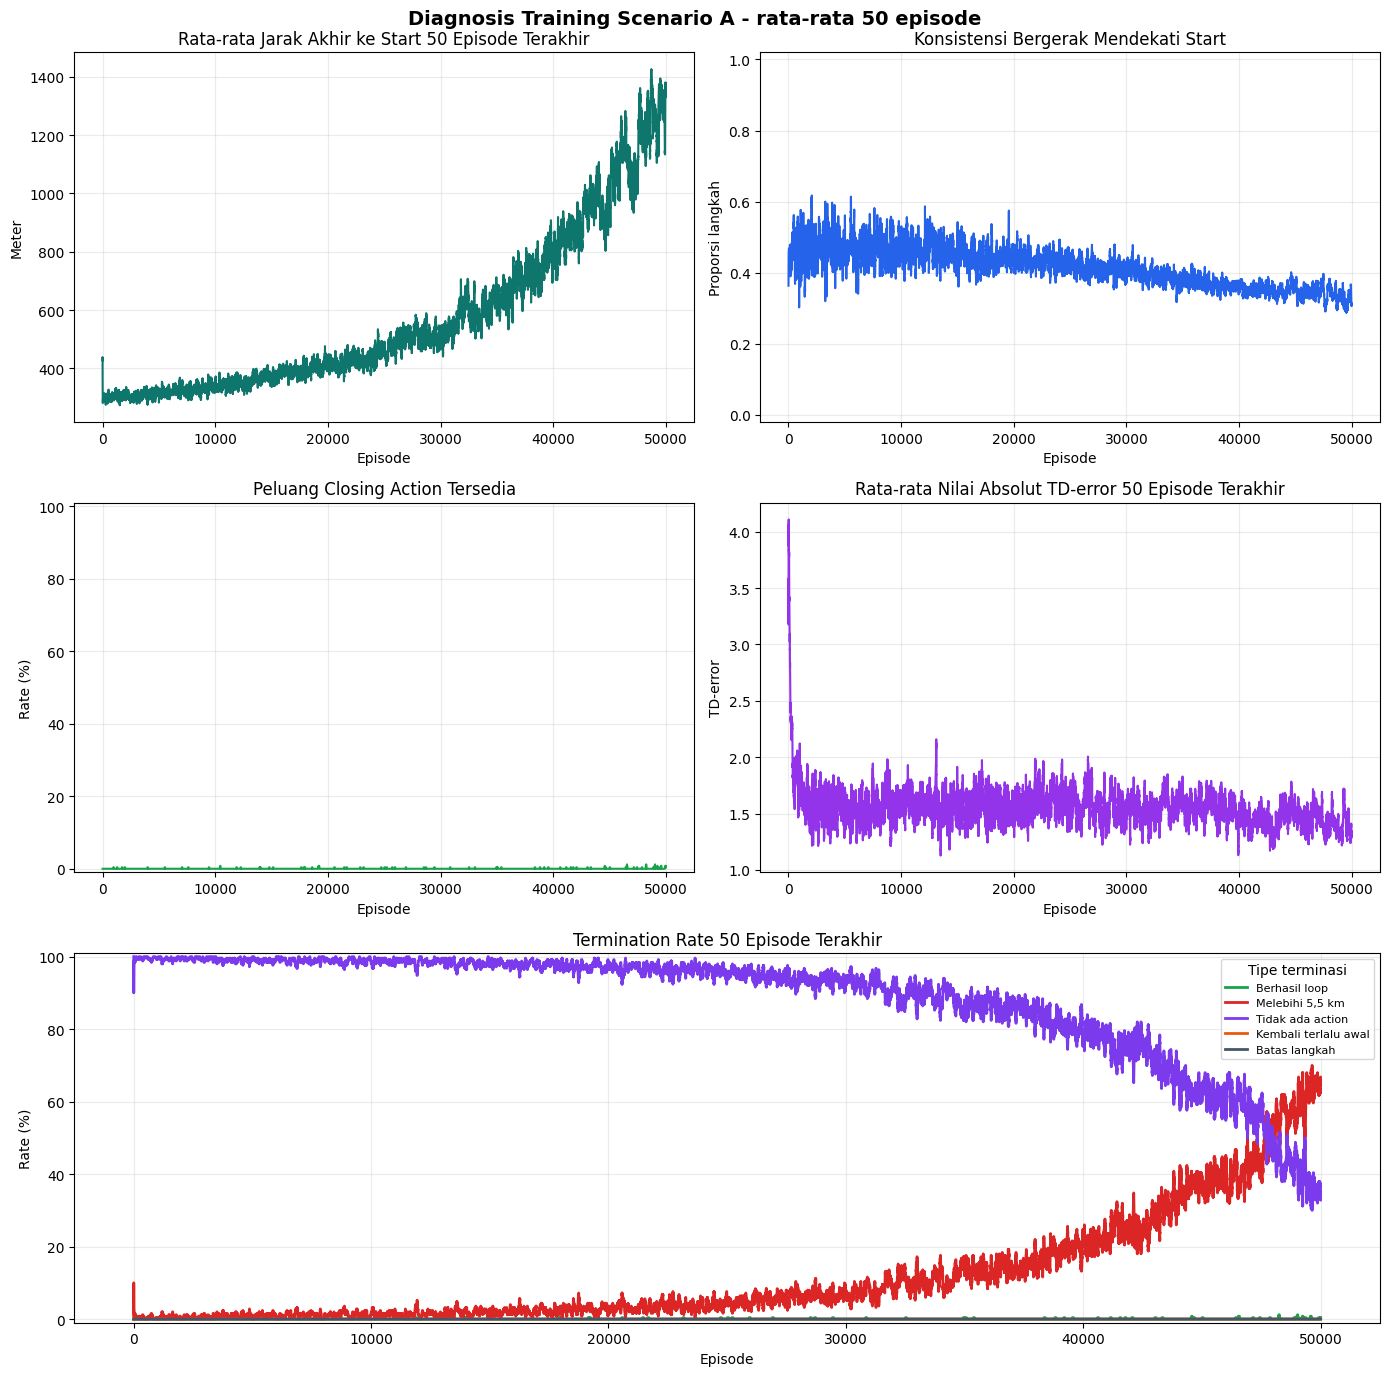

=== Q-TABLE / SEED YANG DIPILIH UNTUK PETA ===
Scenario: A; seed: 3
Metrik: is_loop=False, jarak=5505.99 m, galat=505.99 m, comfort=0.701, return_progress=0.260, jarak akhir ke start=1685.63 m, terminasi=over_distance
Alasan: Tidak ada loop valid, sehingga dipilih rute dengan galat jarak paling kecil; jika setara, jarak akhir ke start paling kecil, comfort tertinggi, lalu return progress tertinggi.


History: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/sensitivitas_epsilon_tetap_50000_episode_50000_A/training_history_A.csv
Evaluasi: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/sensitivitas_epsilon_tetap_50000_episode_50000_A/evaluation_metrics_A.csv
Diagnosis: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/sensitivitas_epsilon_tetap_50000_episode_50000_A/diagnosis_metrics_A.csv
Termination rate training: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/sensitivitas_epsilon_tetap_50000_episode_50000_A/termination_rates_training_A.csv
Termination rate evaluasi: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/sensitivitas_epsilon_tetap_50000_episode_50000_A/termination_rates_evaluation_A.csv
Grafik

In [40]:
import importlib
# Memuat ulang core agar notebook memakai fungsi dan parameter terbaru.
importlib.reload(rute_lari_core)

result_a_fixed_50000 = rute_lari_core.run_scenario_experiment(
    G, START_NODE, 'A',
    episodes=50_000,
    # Epsilon turun hanya pada 50.000 episode pertama, kemudian tetap 0,05.
    epsilon_decay_episodes=50_000,
    result_subdir='sensitivitas_epsilon_tetap_50000_episode_50000_A',
)


### 3.2 Training 75.000 episode dengan epsilon decay 50.000


Menjalankan Scenario A: 5 seed x 75,000 episode
Jadwal epsilon: turun selama 50,000 episode, lalu tetap 0.05
seed=0: over_distance, 5.55 km, is_loop=False
seed=1: over_distance, 5.51 km, is_loop=False
seed=2: over_distance, 5.50 km, is_loop=False
seed=3: over_distance, 5.50 km, is_loop=False
seed=4: no_available_action, 5.15 km, is_loop=False
Tampilan vertikal metrik evaluasi utama per seed


seed,0,1,2,3,4
is_loop,False,False,False,False,False
total_distance_m,5550.496532,5514.680144,5503.030874,5500.944203,5153.992069
absolute_distance_error_m,550.496532,514.680144,503.030874,500.944203,153.992069
total_reward,-86.571918,-80.105101,-93.800084,-58.640383,-55.884971
mean_comfort,0.76407,0.677155,0.689035,0.742567,0.698921
return_progress_ratio,0.390244,0.175,0.17284,0.2,0.255319
distance_to_start_at_end_m,2179.511314,1492.829835,2168.576421,1604.431361,1462.311377
closing_action_available,False,False,False,False,False
termination_reason,over_distance,over_distance,over_distance,over_distance,no_available_action


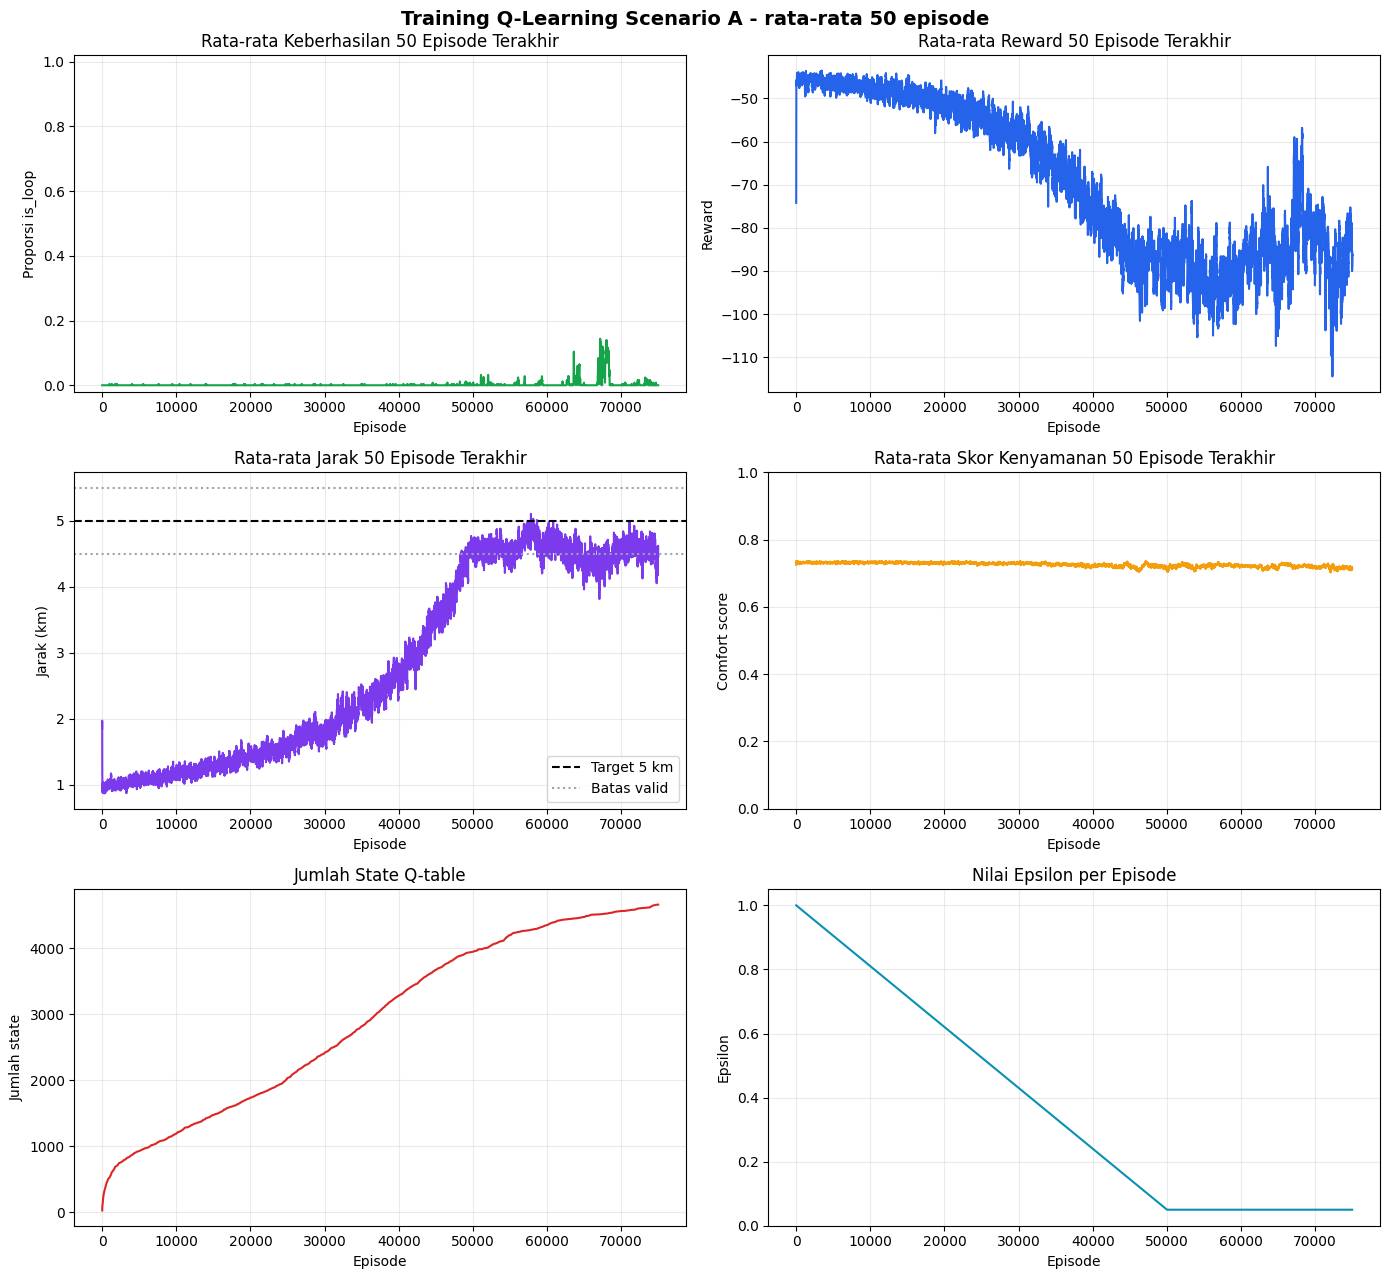

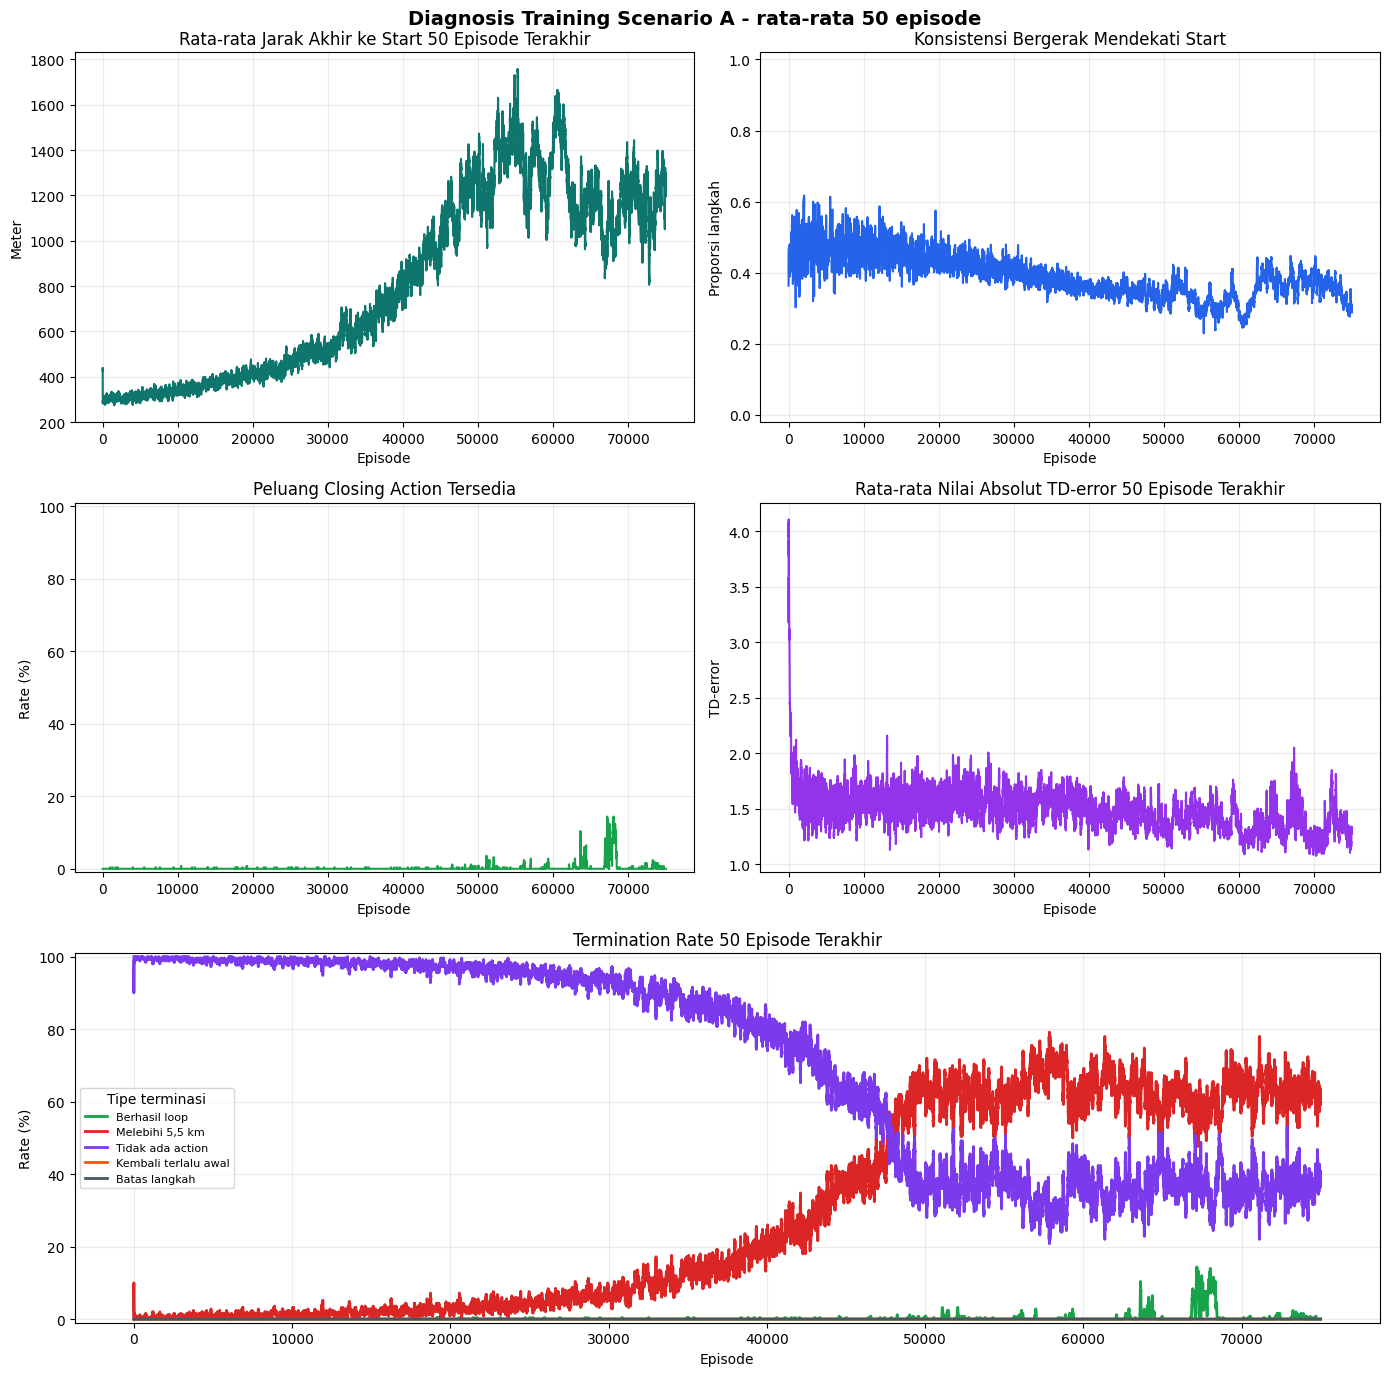

=== Q-TABLE / SEED YANG DIPILIH UNTUK PETA ===
Scenario: A; seed: 4
Metrik: is_loop=False, jarak=5153.99 m, galat=153.99 m, comfort=0.699, return_progress=0.255, jarak akhir ke start=1462.31 m, terminasi=no_available_action
Alasan: Tidak ada loop valid, sehingga dipilih rute dengan galat jarak paling kecil; jika setara, jarak akhir ke start paling kecil, comfort tertinggi, lalu return progress tertinggi.


History: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/sensitivitas_epsilon_tetap_50000_episode_75000_A/training_history_A.csv
Evaluasi: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/sensitivitas_epsilon_tetap_50000_episode_75000_A/evaluation_metrics_A.csv
Diagnosis: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/sensitivitas_epsilon_tetap_50000_episode_75000_A/diagnosis_metrics_A.csv
Termination rate training: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/sensitivitas_epsilon_tetap_50000_episode_75000_A/termination_rates_training_A.csv
Termination rate evaluasi: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/sensitivitas_epsilon_tetap_50000_episode_75000_A/termination_rates_evaluation_A.csv
Grafik

In [41]:
import importlib
# Memuat ulang core agar notebook memakai fungsi dan parameter terbaru.
importlib.reload(rute_lari_core)

result_a_fixed_75000 = rute_lari_core.run_scenario_experiment(
    G, START_NODE, 'A',
    episodes=75_000,
    # Epsilon turun hanya pada 50.000 episode pertama, kemudian tetap 0,05.
    epsilon_decay_episodes=50_000,
    result_subdir='sensitivitas_epsilon_tetap_50000_episode_75000_A',
)


### 3.3 Training 100.000 episode dengan epsilon decay 50.000


Menjalankan Scenario A: 5 seed x 100,000 episode
Jadwal epsilon: turun selama 50,000 episode, lalu tetap 0.05
seed=0: over_distance, 5.73 km, is_loop=False
seed=1: over_distance, 5.51 km, is_loop=False
seed=2: over_distance, 5.53 km, is_loop=False
seed=3: over_distance, 5.52 km, is_loop=False
seed=4: over_distance, 5.54 km, is_loop=False
Tampilan vertikal metrik evaluasi utama per seed


seed,0,1,2,3,4
is_loop,False,False,False,False,False
total_distance_m,5732.485047,5510.75518,5531.362393,5524.234762,5536.999203
absolute_distance_error_m,732.485047,510.75518,531.362393,524.234762,536.999203
total_reward,-261.091273,-40.743483,-79.355164,-52.042215,-58.972988
mean_comfort,0.71793,0.698874,0.690386,0.734298,0.729398
return_progress_ratio,0.54717,0.489796,0.101449,0.75,0.316667
distance_to_start_at_end_m,662.510729,124.594023,2911.277973,374.587921,1165.840124
closing_action_available,False,False,False,False,False
termination_reason,over_distance,over_distance,over_distance,over_distance,over_distance


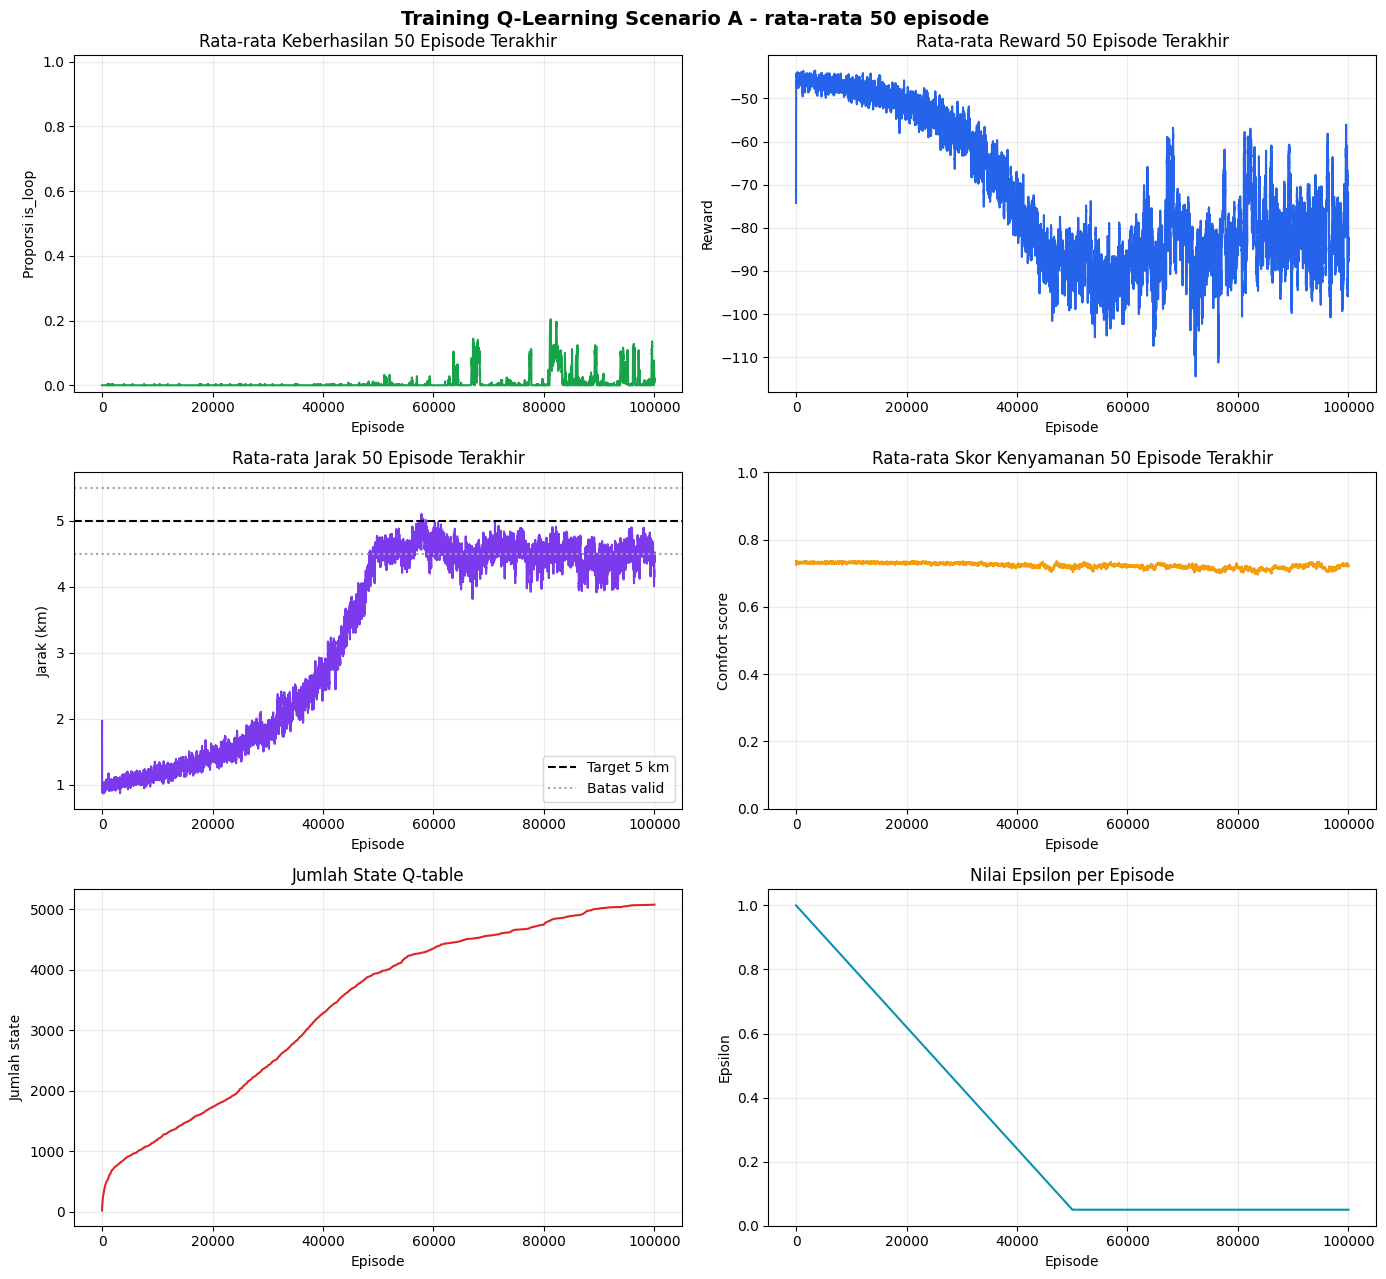

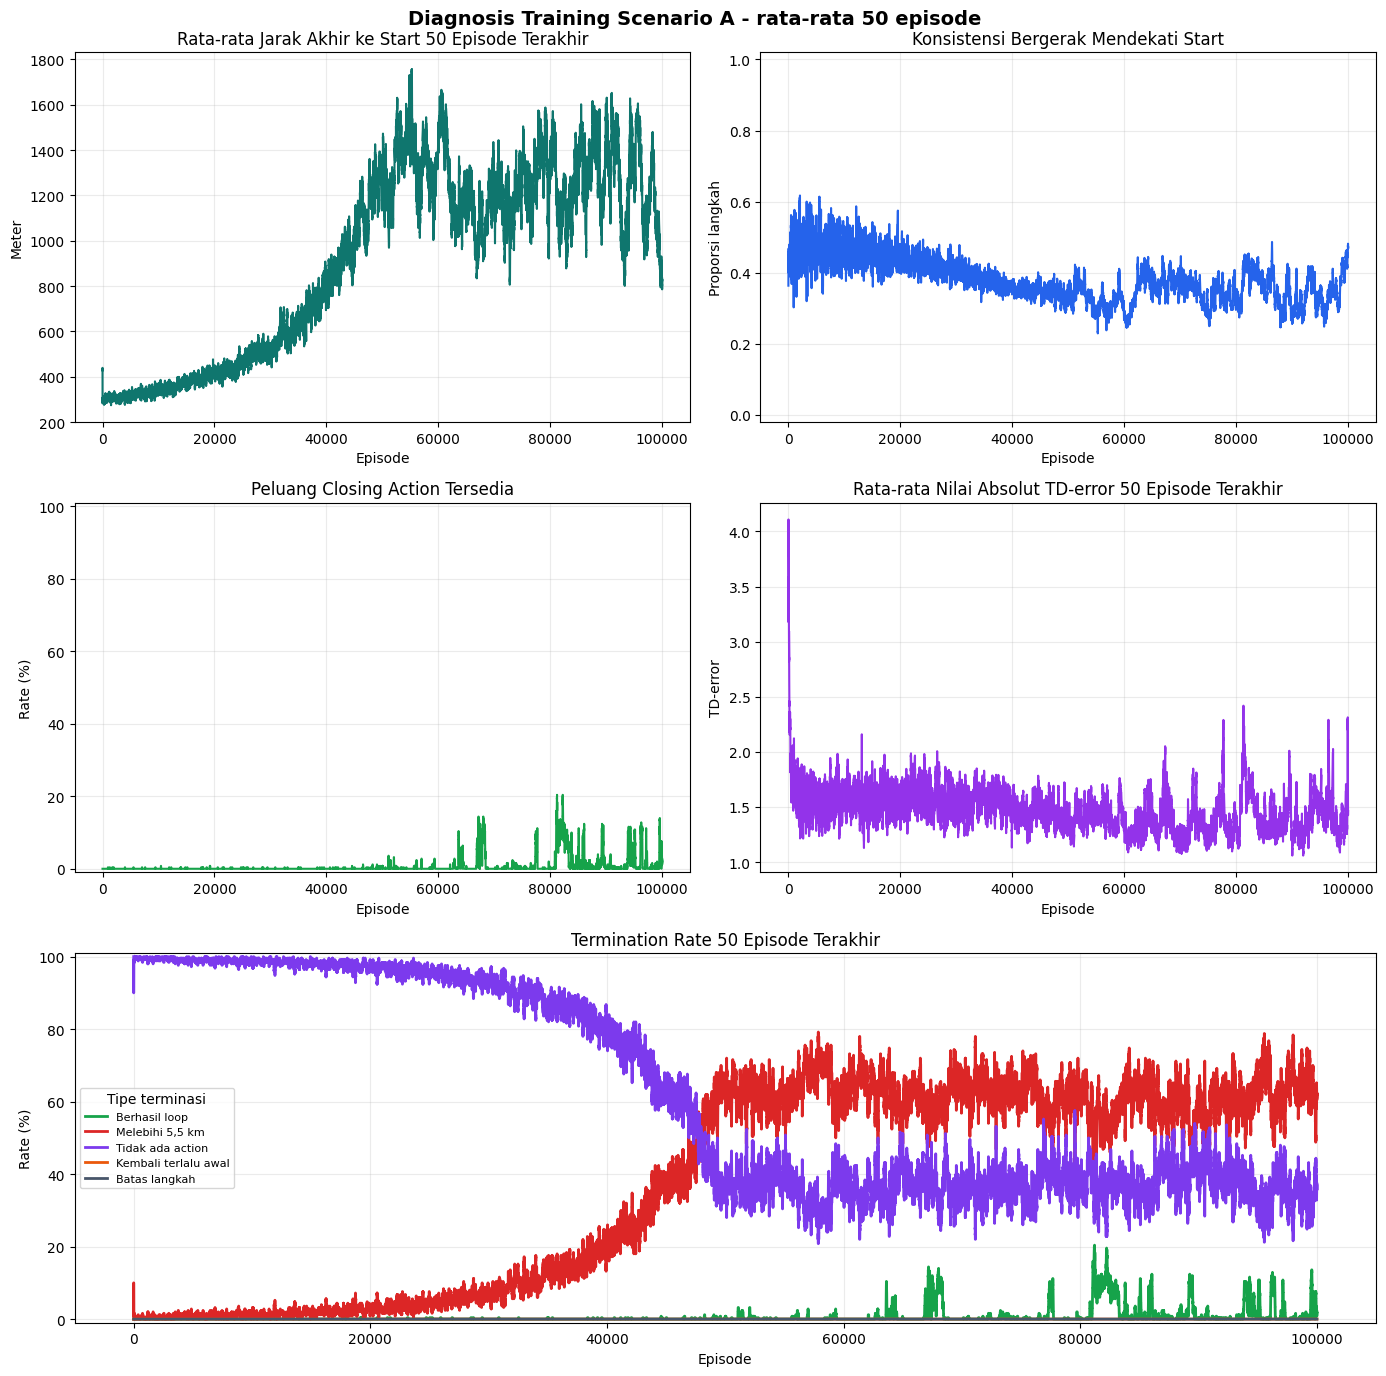

=== Q-TABLE / SEED YANG DIPILIH UNTUK PETA ===
Scenario: A; seed: 1
Metrik: is_loop=False, jarak=5510.76 m, galat=510.76 m, comfort=0.699, return_progress=0.490, jarak akhir ke start=124.59 m, terminasi=over_distance
Alasan: Tidak ada loop valid, sehingga dipilih rute dengan galat jarak paling kecil; jika setara, jarak akhir ke start paling kecil, comfort tertinggi, lalu return progress tertinggi.


History: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/sensitivitas_epsilon_tetap_50000_episode_100000_A/training_history_A.csv
Evaluasi: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/sensitivitas_epsilon_tetap_50000_episode_100000_A/evaluation_metrics_A.csv
Diagnosis: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/sensitivitas_epsilon_tetap_50000_episode_100000_A/diagnosis_metrics_A.csv
Termination rate training: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/sensitivitas_epsilon_tetap_50000_episode_100000_A/termination_rates_training_A.csv
Termination rate evaluasi: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/sensitivitas_epsilon_tetap_50000_episode_100000_A/termination_rates_evaluation_A.csv
G

In [42]:
import importlib
# Memuat ulang core agar notebook memakai fungsi dan parameter terbaru.
importlib.reload(rute_lari_core)

result_a_fixed_100000 = rute_lari_core.run_scenario_experiment(
    G, START_NODE, 'A',
    episodes=100_000,
    # Epsilon turun hanya pada 50.000 episode pertama, kemudian tetap 0,05.
    epsilon_decay_episodes=50_000,
    result_subdir='sensitivitas_epsilon_tetap_50000_episode_100000_A',
)


### 3.4 Training 150.000 episode dengan epsilon decay 50.000


Menjalankan Scenario A: 5 seed x 150,000 episode
Jadwal epsilon: turun selama 50,000 episode, lalu tetap 0.05
seed=0: no_available_action, 1.59 km, is_loop=False
seed=1: no_available_action, 5.38 km, is_loop=False
seed=2: over_distance, 5.55 km, is_loop=False
seed=3: over_distance, 5.52 km, is_loop=False
seed=4: over_distance, 5.58 km, is_loop=False
Tampilan vertikal metrik evaluasi utama per seed


seed,0,1,2,3,4
is_loop,False,False,False,False,False
total_distance_m,1591.969347,5382.736783,5545.606141,5520.525309,5582.947246
absolute_distance_error_m,3408.030653,382.736783,545.606141,520.525309,582.947246
total_reward,-42.667766,-90.999139,-55.975124,-61.128059,-40.198052
mean_comfort,0.71566,0.674418,0.691221,0.706386,0.737262
return_progress_ratio,NaN,0.147059,0.44186,0.116279,0.355556
distance_to_start_at_end_m,386.410849,3384.929471,609.756402,2036.111034,2013.714024
closing_action_available,False,False,False,False,False
termination_reason,no_available_action,no_available_action,over_distance,over_distance,over_distance


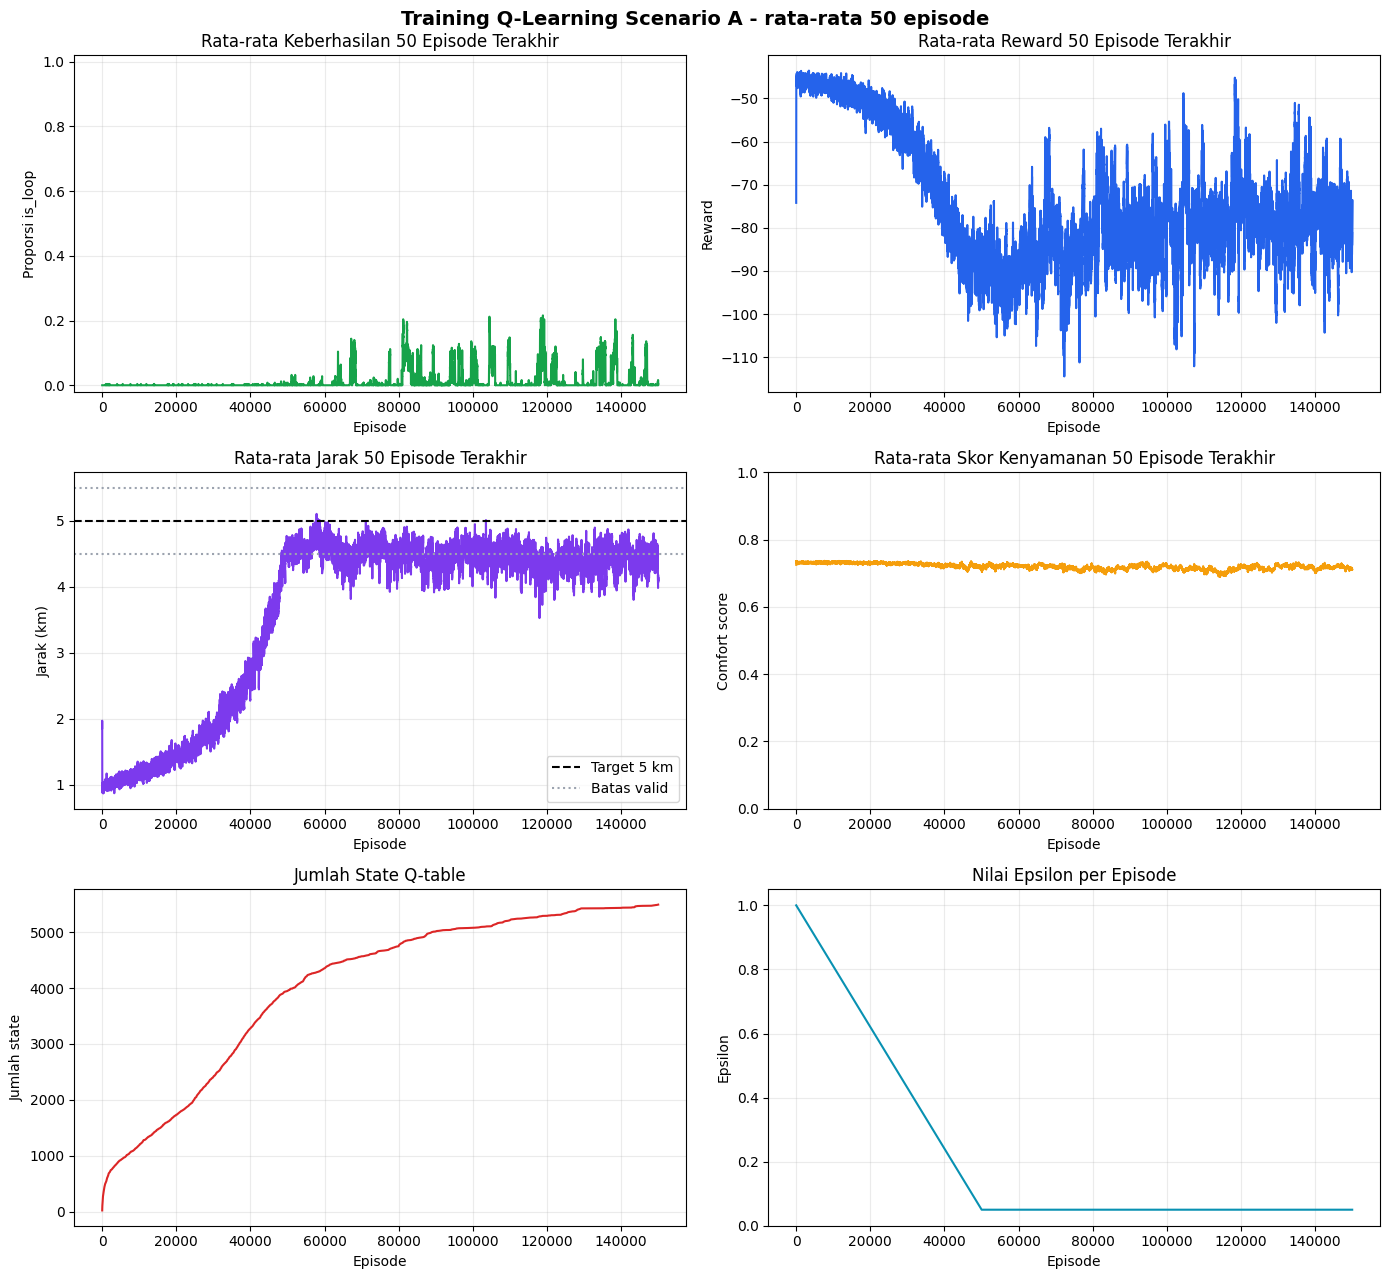

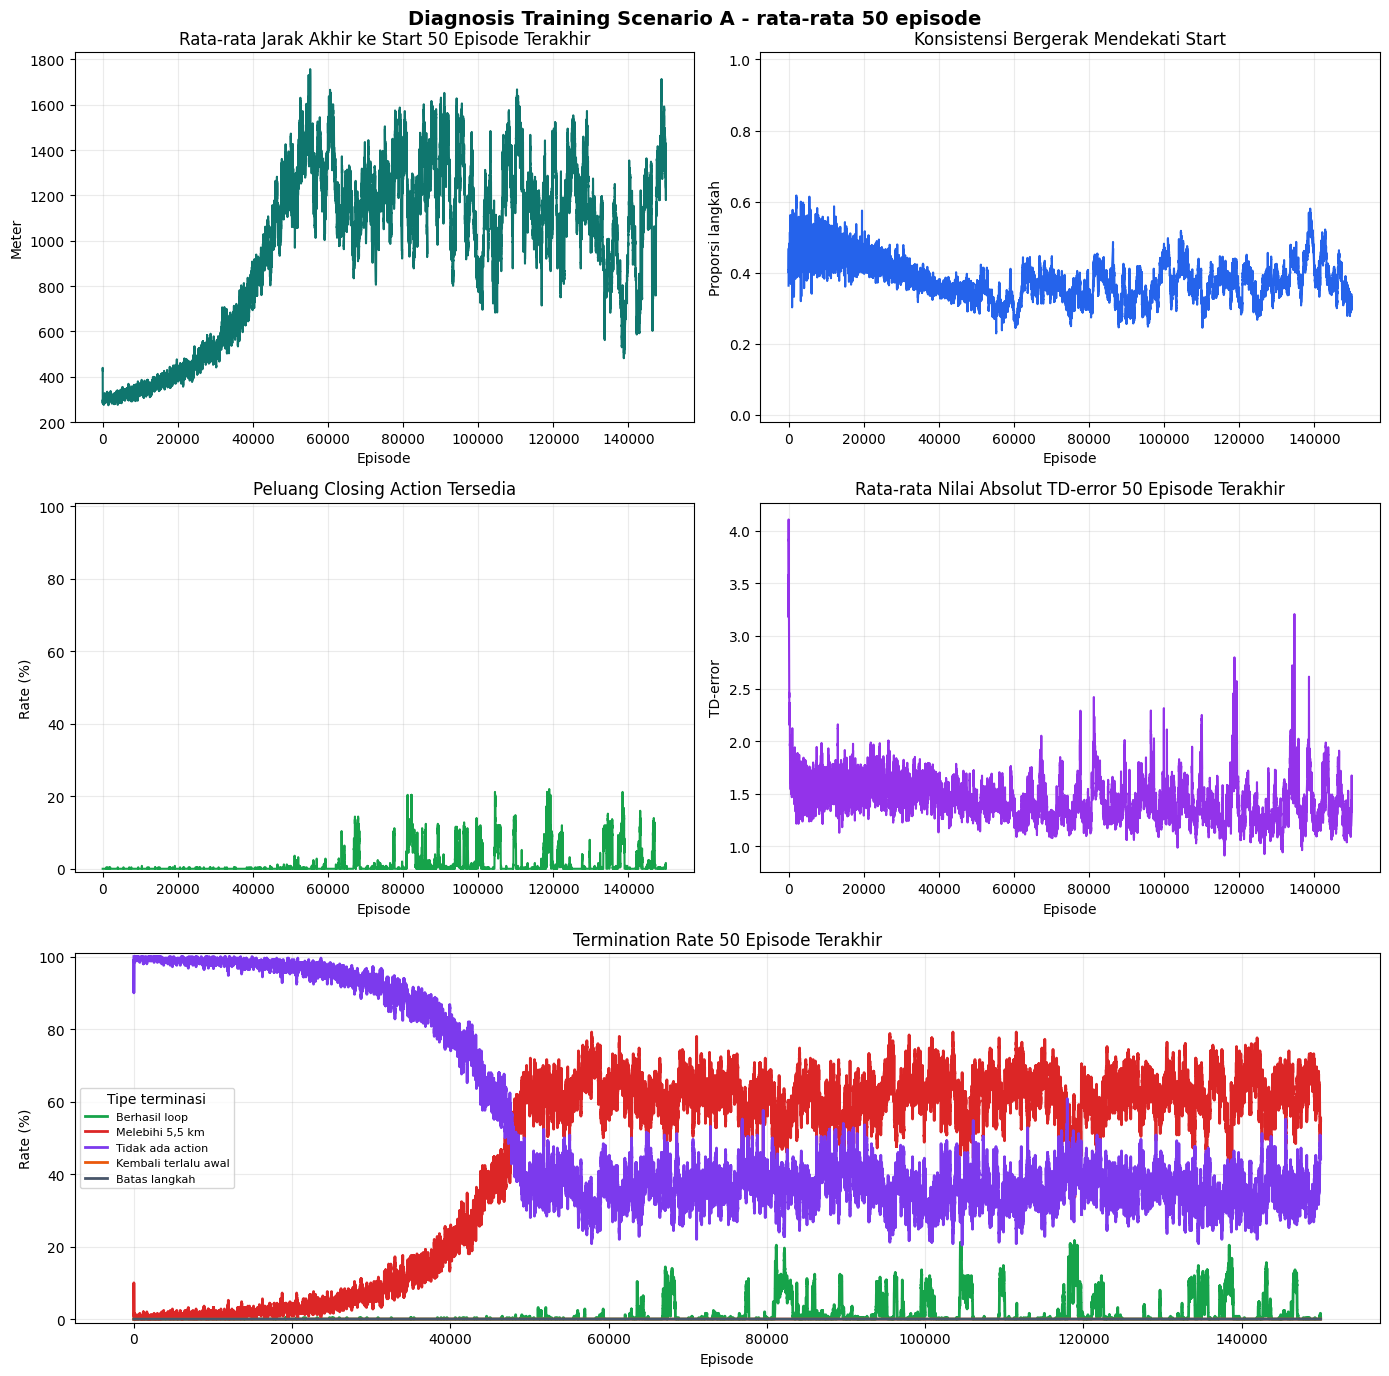

=== Q-TABLE / SEED YANG DIPILIH UNTUK PETA ===
Scenario: A; seed: 1
Metrik: is_loop=False, jarak=5382.74 m, galat=382.74 m, comfort=0.674, return_progress=0.147, jarak akhir ke start=3384.93 m, terminasi=no_available_action
Alasan: Tidak ada loop valid, sehingga dipilih rute dengan galat jarak paling kecil; jika setara, jarak akhir ke start paling kecil, comfort tertinggi, lalu return progress tertinggi.


History: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/sensitivitas_epsilon_tetap_50000_episode_150000_A/training_history_A.csv
Evaluasi: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/sensitivitas_epsilon_tetap_50000_episode_150000_A/evaluation_metrics_A.csv
Diagnosis: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/sensitivitas_epsilon_tetap_50000_episode_150000_A/diagnosis_metrics_A.csv
Termination rate training: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/sensitivitas_epsilon_tetap_50000_episode_150000_A/termination_rates_training_A.csv
Termination rate evaluasi: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/sensitivitas_epsilon_tetap_50000_episode_150000_A/termination_rates_evaluation_A.csv
G

In [43]:
import importlib
# Memuat ulang core agar notebook memakai fungsi dan parameter terbaru.
importlib.reload(rute_lari_core)

result_a_fixed_150000 = rute_lari_core.run_scenario_experiment(
    G, START_NODE, 'A',
    episodes=150_000,
    # Epsilon turun hanya pada 50.000 episode pertama, kemudian tetap 0,05.
    epsilon_decay_episodes=50_000,
    result_subdir='sensitivitas_epsilon_tetap_50000_episode_150000_A',
)


### 3.5 Ringkasan epsilon decay tetap

Tabel dan grafik menggunakan evaluasi greedy lima seed. Karena seluruh titik memakai horizon decay 50.000 episode yang sama, perbedaan hasil terutama mencerminkan tambahan durasi training. TD-error dibaca dari grafik diagnosis pada masing-masing training.


,episodes,epsilon_decay_episodes,success_rate_greedy,mean_distance_error_m,mean_total_reward,mean_comfort,mean_return_progress_ratio,closing_action_available_rate
0,50000,50000,0.0,546.829571,-86.905278,0.712003,0.287898,0.0
1,75000,50000,0.0,444.628764,-75.000491,0.714349,0.238681,0.0
2,100000,50000,0.0,567.167317,-98.441025,0.714177,0.441016,0.0
3,150000,50000,0.0,1087.969227,-58.193628,0.704990,0.265188,0.0


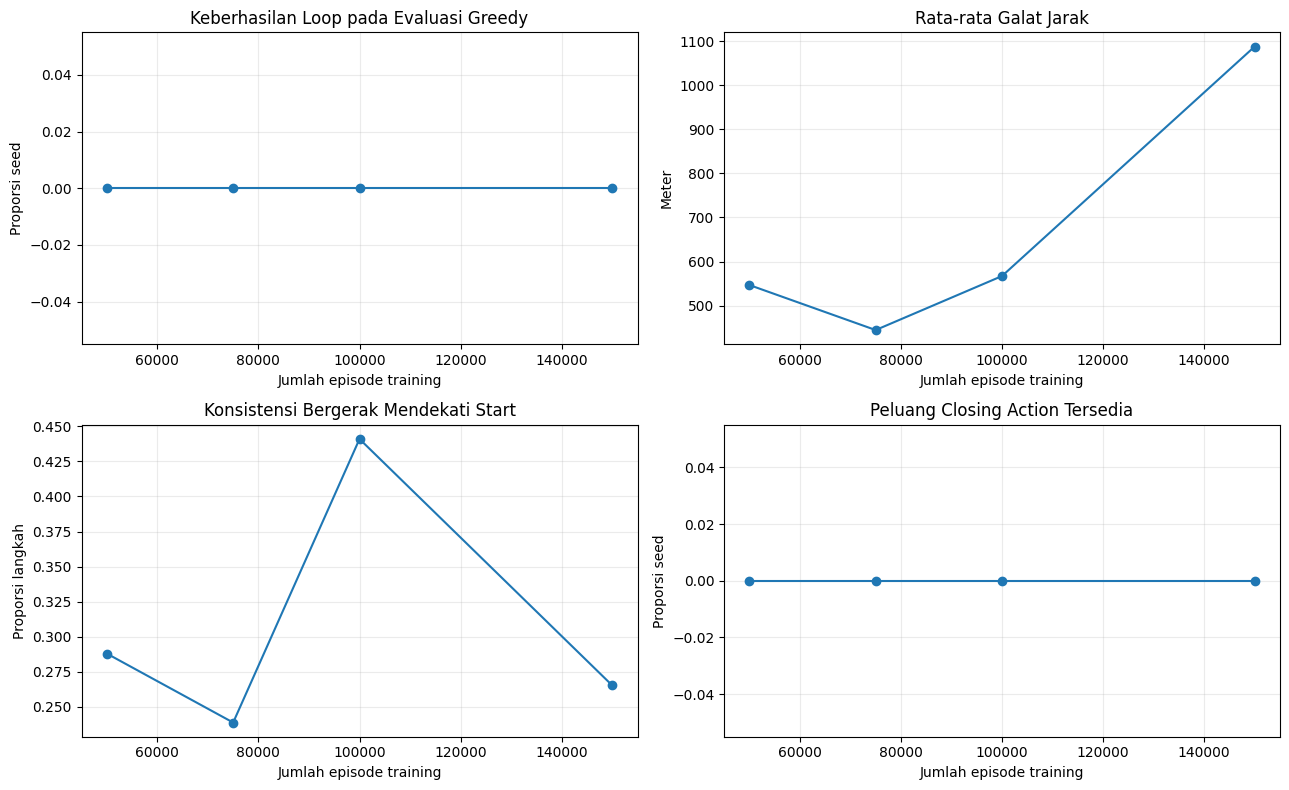

In [44]:
import matplotlib.pyplot as plt
import pandas as pd

# Semua hasil memakai epsilon yang turun selama 50.000 episode pertama, lalu tetap 0,05.
# Perbedaan antar titik terutama berasal dari tambahan durasi training.
fixed_decay_results = {
    50_000: result_a_fixed_50000,
    75_000: result_a_fixed_75000,
    100_000: result_a_fixed_100000,
    150_000: result_a_fixed_150000,
}

summary_rows = []
for episodes, result in fixed_decay_results.items():
    metrics = result['metrics']
    summary_rows.append({
        'episodes': episodes,
        'epsilon_decay_episodes': result['epsilon_decay_episodes'],
        'success_rate_greedy': metrics['is_loop'].mean(),
        'mean_distance_error_m': metrics['absolute_distance_error_m'].mean(),
        'mean_total_reward': metrics['total_reward'].mean(),
        'mean_comfort': metrics['mean_comfort'].mean(),
        'mean_return_progress_ratio': metrics['return_progress_ratio'].mean(),
        'closing_action_available_rate': metrics['closing_action_available'].mean(),
    })

fixed_decay_sensitivity_df = pd.DataFrame(summary_rows).sort_values('episodes')
display(fixed_decay_sensitivity_df)

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
plots = [
    ('success_rate_greedy', 'Keberhasilan Loop pada Evaluasi Greedy', 'Proporsi seed'),
    ('mean_distance_error_m', 'Rata-rata Galat Jarak', 'Meter'),
    ('mean_return_progress_ratio', 'Konsistensi Bergerak Mendekati Start', 'Proporsi langkah'),
    ('closing_action_available_rate', 'Peluang Closing Action Tersedia', 'Proporsi seed'),
]
for axis, (column, title, ylabel) in zip(axes.flat, plots):
    axis.plot(fixed_decay_sensitivity_df['episodes'], fixed_decay_sensitivity_df[column], marker='o')
    axis.set(title=title, xlabel='Jumlah episode training', ylabel=ylabel)
    axis.grid(alpha=0.25)
plt.tight_layout()
plt.show()


## 4. Cara membaca hasil evaluasi

Tabel evaluasi utama memuat `is_loop`, `total_distance_m`, `absolute_distance_error_m`, `total_reward`, `mean_comfort`, `return_progress_ratio`, `distance_to_start_at_end_m`, `closing_action_available`, dan `termination_reason`.

Grafik diagnosis tetap membantu menjelaskan proses training, khususnya termination rate dan ketersediaan closing action.

Baca detail seluruh implementasi di `IMPLEMENTASI.md`.